# IVE Korea — Reward Ad Platform: Fraud Detection, Media Ops & Domain Optimization

**Author's primary contribution:** data integration, missing-value / outlier handling, and the full
fraud (abuse) detection pipeline (Part 1 below). Media Operations Management and Domain Ad
Optimization (Parts 2-3) were built by teammates and are included here for pipeline continuity;
they are documented more lightly since they are not the author's individual work.

## Project context

IVE Korea runs a reward-based ad platform: users complete ad actions (install / launch / quiz /
purchase, etc.) through partner media (`mda`) and receive point rewards. The core business problem:
**abusive / bot traffic silently inflates click volume and distorts CVR, margin, and every
downstream media/advertiser decision** unless it is detected and removed first.

## What this notebook does, end to end

| Part | Scope | Owner |
|---|---|---|
| 1 | Data integration, cleaning, feature engineering, fraud detection, loss quantification, 1-year validation | **Author (this notebook's focus)** |
| 2 | Media-level KPI segmentation & operational recommendation (confirmed / potential / improve / reduce) | Team |
| 3 | Domain x ad-type strategic optimization | Team |

## Data model (grain of each table)

| Table | Grain (1 row =) | Key columns |
|---|---|---|
| `df_master` (ad catalog) | 1 ad campaign (`ads_idx`) | type, domain, price, schedule |
| `df_engagement` (clicks) | 1 user click / ad participation event (`click_key`) | device, IP, media, cost |
| `df_reward` (conversions) | 1 completed / rewarded action (`click_key`, subset of engagement) | CTIT, cost breakdown |
| `df_report` (hourly report, 1 year) | 1 (date, hour, ad, media) bucket | click/conversion/cost aggregates |

`click_key` is the join key between engagement and reward — it is generated at the moment the
partner page calls back to report a completed user action (see sequence diagram below).
Every click_key in `df_reward` must exist in `df_engagement`; the reverse is not true (most clicks
never convert).

```
User -> IVE server -> Partner page -> Advertiser server
  1. User participates via offerwall            -> IVE stores ads_idx
  2. IVE calls the partner participation page    -> user action happens on partner side
  3. Partner reports the action to advertiser
     opt [action succeeded]  -> partner calls back to IVE with ads_idx  (== click_key created)
     opt [validation passed] -> IVE grants points to the user
```

## Cost structure (who pays whom)

| Field | Meaning | Flow |
|---|---|---|
| `show_cost` / `rpt_time_scost` | amount shown to the advertiser | Advertiser pays this |
| `adv_cost` / `rpt_time_acost` | amount IVE actually charges | IVE receives this |
| `earn_cost` / `rpt_time_earn` | amount owed to the media partner | IVE pays media |
| `rwd_cost` / `rpt_time_cost` | amount paid to the user | Media pays user |

By construction `show_cost >= adv_cost >= earn_cost >= rwd_cost >= 0`; any row that violates this
ordering is a data-integrity error and is removed in preprocessing (Part 1, Step 2).

## Hypotheses this analysis tests (Part 1)

- **H1 (speed):** a completed action faster than is physically possible for a human (near-zero
  click-to-install time) indicates automated / scripted completion.
- **H2 (device farm):** an unusually large number of distinct devices behind a single IP indicates
  emulator farms or device farms rather than organic users.
- **H3 (click farm):** an unusually large number of clicks from a single IP indicates scripted
  repeat participation.
- **H4 (concentration):** if H1-H3 hold, abusive traffic should be concentrated in a small number
  of media partners and in specific ad types (low-friction, high click-volume types), not spread
  evenly across the platform.
- **H5 (temporal signature):** if traffic is bot-driven rather than human, it should NOT follow
  human activity rhythms (daytime peaks, weekday/weekend gaps) the way normal traffic does.

Each hypothesis is tested with real numbers in the corresponding step below.


---
# PART 1. Data Integration & Fraud Detection

Analysis window: **2025-07-26 ~ 2025-08-25** (31 days) for click/reward/master tables.
`df_report` covers a full year (2024-07-27 ~ 2025-08-29) and is used later for time-series
validation (Steps 13-19).


## Step 1. Load data & basic preprocessing

In [261]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 11,
})
PALETTE = {
    'critical': '#c0392b', 'risky': '#e67e22', 'warning': '#f1c40f', 'normal': '#2ecc71',
    'outlier': '#c0392b', 'abusing': '#e67e22', 'non_rewarded': '#95a5a6', 'clean_normal': '#2ecc71',
}

# Paths are relative to a local ./data folder — replace with your own path when re-running.
df_master    = pd.read_csv('/Users/joshuakim/Desktop/데이터 모음 (프로젝트용)/아이브코리아/최종 프로젝트 코드 모음/아이브 코리아 데이터/광고 목록_도메인 라벨링_결측치처리.csv', low_memory=False)
df_reward    = pd.read_csv('/Users/joshuakim/Desktop/데이터 모음 (프로젝트용)/아이브코리아/최종 프로젝트 코드 모음/아이브 코리아 데이터/IVE_광고적립_all.csv', low_memory=False)
df_engagement= pd.read_csv('/Users/joshuakim/Desktop/데이터 모음 (프로젝트용)/아이브코리아/최종 프로젝트 코드 모음/아이브 코리아 데이터/IVE_광고참여정보_all.csv', low_memory=False)
df_report    = pd.read_csv('/Users/joshuakim/Desktop/데이터 모음 (프로젝트용)/아이브코리아/최종 프로젝트 코드 모음/아이브 코리아 데이터/아이브시간대별광고리포트_1년치_all.csv', low_memory=False)

In [262]:
ANALYSIS_START = pd.to_datetime('2025-07-26')
ANALYSIS_END   = pd.to_datetime('2025-08-25')

# Sentinel-date fix: the raw catalog uses "9999-12-31" as a placeholder for "no defined end
# date" -- 430,501 of 445,260 ads (96.7%). Replacing the sentinel in the raw STRING before
# parsing to datetime avoids a real pitfall: parsing a year-9999 timestamp and then clipping
# it can silently produce NaT instead of the intended value on some pandas versions, since
# 9999 falls outside the legal Timestamp range on those versions. Matching on substring
# containment ('9999' anywhere in the string) rather than an anchored prefix is deliberately
# permissive, so format variants (different separators, leading whitespace) are still caught.
ANALYSIS_LATEST_DATE = '2025-08-29'
edate_raw = df_master['ads_edate'].astype(str)
is_sentinel = edate_raw.str.contains('9999', na=False)
df_master['ads_edate'] = edate_raw.where(~is_sentinel, ANALYSIS_LATEST_DATE)
print(f"ads_edate: sentinel rows replaced: {is_sentinel.sum():,} of {len(df_master):,}")

for col in ['regdate', 'ads_sdate', 'ads_edate']:
    df_master[col] = pd.to_datetime(df_master[col], errors='coerce')
print(f"ads_edate: unparseable after sentinel fix (NaT): {df_master['ads_edate'].isna().sum()}  "
      f"-- genuinely malformed/missing dates, distinct from the 9999-sentinel rows above")

AD_TYPE_MAP = {
    1: 'install', 2: 'launch', 3: 'participation', 4: 'click_type',
    5: 'facebook', 6: 'twitter', 7: 'instagram', 8: 'display',
    9: 'quest', 10: 'youtube', 11: 'naver', 12: 'CPS(purchase)'
}
# Canonical domain map, defined once and reused everywhere in this notebook.
DOMAIN_MAP = {1: 'entertainment', 2: 'finance', 3: 'lifestyle', 4: 'commerce', 5: 'other'}

ads_edate: sentinel rows replaced: 430,501 of 445,260
ads_edate: unparseable after sentinel fix (NaT): 14759  -- genuinely malformed/missing dates, distinct from the 9999-sentinel rows above


### 1a. Domain-label correction

The initial domain labels come from a rule-based + Gemini LLM hybrid classifier (see README for
the full method). A manual spot-check of 100 random ads (94% agreement) surfaced ~6-7 clear
misclassifications, concentrated almost entirely in the `other` bucket (the classifier's catch-all
for anything it wasn't confident about) plus one game miscategorized as `commerce`. One clear
internal inconsistency was also found: the same offline vape-shop chain ("전담GATE") appeared with
two different domain labels across two different ads.

This runs on `df_master` before anything is copied or joined from it, so every later step (risk
scoring, media KPIs, domain optimization) sees the same corrected label.

In [263]:
domain_label_fixes = {
    1: ['원스토어'],  # OneStore-listed mobile games mislabeled as commerce -> entertainment
    4: [
        '에어매쉬토퍼', '시어서커 패드', '바디필로우', '마사지건', '다이어트',
        '액정보호필름', '타공기', '아쿠아디지오', '아르마니', '윈드배너',
    ],  # physical / cosmetic products mislabeled as lifestyle or other -> commerce
}
for target_label, keywords in domain_label_fixes.items():
    for kw in keywords:
        mask = df_master['ads_name'].str.contains(kw, na=False)
        n = int(mask.sum())
        if n > 0:
            df_master.loc[mask, 'domain_label'] = target_label
            print(f"'{kw}' matched {n} ads -> reclassified to domain_label {target_label}")

'원스토어' matched 623 ads -> reclassified to domain_label 1
'에어매쉬토퍼' matched 2 ads -> reclassified to domain_label 4
'시어서커 패드' matched 2 ads -> reclassified to domain_label 4
'바디필로우' matched 129 ads -> reclassified to domain_label 4
'마사지건' matched 12 ads -> reclassified to domain_label 4
'다이어트' matched 365 ads -> reclassified to domain_label 4
'액정보호필름' matched 51 ads -> reclassified to domain_label 4
'타공기' matched 11 ads -> reclassified to domain_label 4
'아쿠아디지오' matched 8 ads -> reclassified to domain_label 4
'아르마니' matched 11 ads -> reclassified to domain_label 4
'윈드배너' matched 8 ads -> reclassified to domain_label 4


> **Known limitation (documented, not hidden):** this is a targeted patch for the errors found
> during a 100-row manual audit, not a full re-labeling. The `other` domain in particular should
> be audited in full before this pipeline is used for a real budget decision — see README
> "Known Limitations".

In [264]:
# df_master2: full-row copy of the (now domain-corrected) catalog, taken BEFORE the Step-2
# cost-outlier filter. Kept for joins/labeling that need every ad row (CTIT median calc,
# df_integrated / df_report joins). Everything below inherits the Step-1a fix automatically
# because it copies from the already-corrected df_master.
df_master2 = df_master.copy()
df_master2['ads_type_name'] = df_master2['ads_type'].map(AD_TYPE_MAP)
df_master2['domain_name']   = df_master2['domain_label'].map(DOMAIN_MAP)

df_reward['advid'] = df_reward['advid'].fillna('Unknown')

df_engagement = (
    df_engagement
    .drop(columns=['carrier'])          # >97% missing, not usable
    .assign(network=lambda x: x['network'].fillna('Unknown'))
    .dropna(subset=['user_ip'])         # IP is required for the fraud-detection features below
    .reset_index(drop=True)
)

## Step 2. Cost-structure outlier removal — Data Quality Checkpoint #1

**Rule:** for every cost record, `advertiser payment >= IVE take >= media payout >= user reward >= 0`
must hold (this is a real accounting identity in the reward-ad business). Rows that violate it, or
that are exactly zero where they shouldn't be, are data errors and are dropped before any
analysis — not "abuse", just broken rows.

In [265]:
before_master = len(df_master)
df_master = df_master[
    (df_master['ads_contract_price'] >= df_master['ads_reward_price']) &
    (df_master['ads_contract_price'] > 0) &
    (df_master['ads_reward_price']   >= 0)   # explicit non-negativity, not just implied by >=
].reset_index(drop=True)

before_engagement = len(df_engagement)
df_engagement = df_engagement[
    (df_engagement['adv_price']      >= df_engagement['contract_price']) &
    (df_engagement['contract_price'] >= df_engagement['media_price']) &
    (df_engagement['media_price']    >= df_engagement['reward_price']) &
    (df_engagement[['adv_price', 'contract_price', 'media_price']].min(axis=1) > 0) &
    (df_engagement['reward_price'] >= 0)
].reset_index(drop=True)

before_reward = len(df_reward)
df_reward = df_reward[
    (df_reward['show_cost'] >= df_reward['adv_cost']) &
    (df_reward['adv_cost']  >= df_reward['earn_cost']) &
    (df_reward['earn_cost'] >= df_reward['rwd_cost']) &
    (df_reward[['show_cost', 'adv_cost', 'earn_cost']].min(axis=1) > 0) &
    (df_reward['rwd_cost'] >= 0)
].reset_index(drop=True)

# a reward row with no matching engagement row is itself an integrity error
valid_click_keys = set(df_engagement['click_key'])
before_orphan = len(df_reward)
df_reward = df_reward[df_reward['click_key'].isin(valid_click_keys)].reset_index(drop=True)

print("[Data Quality Checkpoint #1 — cost-structure integrity]")
print(f"  ad_catalog   : {before_master:>10,} -> {len(df_master):>10,}  ({before_master-len(df_master):>7,} removed, "
      f"{(before_master-len(df_master))/before_master*100:.2f}%)")
print(f"  engagement   : {before_engagement:>10,} -> {len(df_engagement):>10,}  "
      f"({before_engagement-len(df_engagement):>7,} removed, "
      f"{(before_engagement-len(df_engagement))/before_engagement*100:.2f}%)")
print(f"  reward       : {before_reward:>10,} -> {len(df_reward):>10,}  ({before_reward-len(df_reward):>7,} removed, "
      f"{(before_reward-len(df_reward))/before_reward*100:.2f}%)")
print(f"  reward orphans (no matching click): {before_orphan-len(df_reward)}")

# Merge-integrity guard -- silent row explosion is the single easiest way for a multi-table
# merge pipeline to quietly produce wrong numbers at this scale (16M+ rows). The
# non-negativity checks above kept in place even though no row is currently dropped by them
# (reward_price / rwd_cost < 0 never occurs in this dataset) -- the absence of a violation
# today doesn't guarantee one can't appear in a future data pull.
assert df_reward['click_key'].duplicated().sum() == 0, "df_reward click_key is not unique"
print("  merge-integrity check passed: reward.click_key is unique (required for a 1:1 merge later)")

[Data Quality Checkpoint #1 — cost-structure integrity]
  ad_catalog   :    445,260 ->    444,693  (    567 removed, 0.13%)
  engagement   : 16,854,856 -> 16,831,054  ( 23,802 removed, 0.14%)
  reward       :  1,475,031 ->  1,470,533  (  4,498 removed, 0.30%)
  reward orphans (no matching click): 81
  merge-integrity check passed: reward.click_key is unique (required for a 1:1 merge later)


## Step 3. Feature engineering — the 3 fraud signals (tests H1, H2, H3)

In [266]:
# ── H1: click-to-install time (CTIT) ──────────────────────────────────────
# A conversion that lands below ~10% of the type-specific median CTIT is treated as an
# empirically extreme short-CTIT outlier -- this is a statistical heuristic relative to this
# platform's own distribution, not a claim about physical human reaction-time limits.
# click_type (=4) has a legitimate CTIT of 0, so it is handled separately: for that type,
# CTIT==0 IS the error signal (it means the "click" and "conversion" timestamp were never
# really distinct events).
df_reward['is_rewarded_flag'] = 1  # reward-table membership IS the conversion definition
ctit_tmp = df_reward[['ads_idx', 'ctit']].merge(
    df_master2[['ads_idx', 'ads_type']], on='ads_idx', how='left', validate='many_to_one'
)
ctit_threshold_by_type = (
    ctit_tmp[ctit_tmp['ads_type'] != 4]
    .groupby('ads_type')['ctit'].median() * 0.1
).to_dict()

ctit_tmp['threshold'] = ctit_tmp['ads_type'].map(ctit_threshold_by_type)
is_ctit_error = (
    ((ctit_tmp['ads_type'] == 4) & (ctit_tmp['ctit'] == 0)) |
    ((ctit_tmp['ads_type'] != 4) & (ctit_tmp['ctit'] < ctit_tmp['threshold']))
)
df_reward['ctit_error'] = np.where(is_ctit_error.values, 'Y', 'N')

# ── H2 / H3: device-farm & click-farm signals ────────────────────────────
# device_count = distinct devices seen from one (media, IP) pair
# click_count   = total clicks from one (media, IP) pair
ip_stats = (
    df_engagement
    .groupby(['mda_idx', 'user_ip'])
    .agg(device_count=('dvc_idx', 'nunique'), click_count=('click_key', 'count'))
    .reset_index()
)
print(f"IP-level stat rows: {len(ip_stats):,}")

IP-level stat rows: 962,174


## Step 4. Build the integrated click-level table

In [267]:
# Merge-integrity guard before the big multi-table merge -- validate= makes pandas raise
# instead of silently exploding rows if a join key turns out not to be unique on one side.
assert df_master2['ads_idx'].duplicated().sum() == 0, "ads_idx must be unique in the ad catalog"

df_integrated = (
    df_engagement
    .merge(df_reward,  on='click_key',            how='left', validate='one_to_one', suffixes=('', '_reward'))
    .merge(df_master2, on='ads_idx',               how='left', validate='many_to_one', suffixes=('', '_master'))
    .merge(ip_stats,   on=['mda_idx', 'user_ip'],  how='left', validate='many_to_one')
)
# Conversion is defined by reward-table MEMBERSHIP, not by whether ctit happens to be
# non-null. is_rewarded_flag was set to 1 on every df_reward row before the merge (Step 3),
# so a row that matched but has a missing ctit still correctly counts as converted -- ctit
# itself being missing becomes a separate data-quality flag, not a silent misclassification.
# (Verified empirically that this dataset has zero rows where the two definitions would have
# actually disagreed -- ctit is never null in df_reward -- so the numbers below are unchanged
# from the old ctit.notna() definition; the fix removes a latent risk, not an active bug.)
df_integrated['is_rewarded'] = df_integrated['is_rewarded_flag'].fillna(0).astype(int)
df_integrated['ctit_missing'] = df_integrated['is_rewarded'].eq(1) & df_integrated['ctit'].isna()
print(f"df_integrated rows: {len(df_integrated):,}  |  is_rewarded=1 (converted): {df_integrated['is_rewarded'].sum():,}  "
      f"|  converted-but-ctit-missing: {df_integrated['ctit_missing'].sum()}")

df_integrated rows: 16,831,054  |  is_rewarded=1 (converted): 1,470,533  |  converted-but-ctit-missing: 0


## Step 5. Row-level classification (tests H2 & H3 quantitatively)

Grading rule for `device_count` and `click_count` (percentile within each metric, across all
media x IP pairs):

| Grade | Rule |
|---|---|
| outlier | top 0.1% |
| risky   | top 1.0% (excl. outlier) |
| warning | top 5.0% (excl. risky/outlier) |
| normal  | remaining 95% |

`row_label` (final call per click) -- terminology note: this pipeline uses purely statistical
percentile thresholds on this platform's own traffic, with no independently verified ground
truth (no confirmed-invalid-traffic or settlement-rejection labels available). So `outlier` here
means **empirically extreme relative to this platform's own distribution**, not a legal or
contractual determination of fraud -- see the terminology table in the Part 1 summary for how
this is phrased in every user-facing sentence below.

- **non_rewarded** — never converted (no cost, not itself a decision point for anomaly status)
- **outlier** — any one of the 3 metrics hit the 0.1% extreme band -> high-confidence anomaly,
  candidate for settlement deduction regardless of the other two metrics
- **abusing** — not extreme, but at least one metric is in the risky/warning band -> flagged for
  monitoring, not automatically deducted
- **normal** — every metric normal

In [268]:
d_crit = ip_stats['device_count'].quantile(0.999)
d_dang = ip_stats['device_count'].quantile(0.99)
d_warn = max(2, ip_stats['device_count'].quantile(0.95))
c_crit = ip_stats['click_count'].quantile(0.999)
c_dang = ip_stats['click_count'].quantile(0.99)
c_warn = ip_stats['click_count'].quantile(0.95)

print(f"[Device-count thresholds]  normal<={d_warn:.0f}  warning~{d_dang:.0f}  risky~{d_crit:.0f}  outlier>{d_crit:.0f}")
print(f"[Click-count thresholds]   normal<={c_warn:.0f}  warning~{c_dang:.0f}  risky~{c_crit:.0f}  outlier>{c_crit:.0f}")

ip_stats['device_grade'] = np.select(
    [ip_stats['device_count'] <= d_warn, ip_stats['device_count'] <= d_dang, ip_stats['device_count'] <= d_crit],
    ['normal', 'warning', 'risky'], default='outlier')
ip_stats['click_grade'] = np.select(
    [ip_stats['click_count'] <= c_warn, ip_stats['click_count'] <= c_dang, ip_stats['click_count'] <= c_crit],
    ['normal', 'warning', 'risky'], default='outlier')

df_integrated = df_integrated.merge(
    ip_stats[['mda_idx', 'user_ip', 'device_grade', 'click_grade']],
    on=['mda_idx', 'user_ip'], how='left', validate='many_to_one'
)
df_integrated['device_grade'] = df_integrated['device_grade'].fillna('normal')
df_integrated['click_grade']  = df_integrated['click_grade'].fillna('normal')

# ctit_grade only ever takes 3 values: a click either never converted (non_rewarded), or it
# converted and its CTIT was either extreme (outlier) or not (normal). There is deliberately
# no "risky"/"warning" band for CTIT -- unlike device/click count, a single click's CTIT is
# either past the extreme-speed threshold or it isn't; there's no aggregate signal to build a
# softer middle band from the way there is for repeat-IP behavior.
df_integrated['ctit_grade'] = np.select(
    [df_integrated['ctit_error'].isna(), df_integrated['ctit_error'] == 'Y', df_integrated['ctit_error'] == 'N'],
    ['non_rewarded', 'outlier', 'normal'], default='non_rewarded')

is_outlier = ((df_integrated['ctit_grade']=='outlier') | (df_integrated['device_grade']=='outlier')
              | (df_integrated['click_grade']=='outlier'))
# IMPORTANT: device_grade/click_grade are IP-level properties that apply to a click whether
# or not it converted (they're aggregated over ALL engagement from that (media, IP) pair).
# So `abusing` must be checked BEFORE `non_rewarded` in the priority order below --
# otherwise every non-converted click from a risky IP gets silently absorbed into
# `non_rewarded` instead of being flagged.
is_abusing = ((df_integrated['device_grade'].isin(['warning','risky'])) |
              (df_integrated['click_grade'].isin(['warning','risky'])))
is_non_rewarded = df_integrated['is_rewarded'] == 0

df_integrated['row_label'] = np.select(
    [is_outlier, is_abusing, is_non_rewarded],
    ['outlier', 'abusing', 'non_rewarded'], default='normal'
)
print(f"\n[row_label distribution]\n{df_integrated['row_label'].value_counts()}")

[Device-count thresholds]  normal<=3  warning~6  risky~88  outlier>88
[Click-count thresholds]   normal<=37  warning~258  risky~934  outlier>934

[row_label distribution]
row_label
abusing         7782515
outlier         6387902
non_rewarded    1849072
normal           811565
Name: count, dtype: int64


**H2/H3 confirmed:** the 0.1%-tail devices/clicks-per-IP thresholds land at 88 devices and 934
clicks from a single IP — numbers with no plausible organic explanation. 38% of all clicks in the
window (6.39M) fall in the high-confidence-anomaly (`outlier`) band, and another 46% (7.78M) are flagged
for monitoring (`abusing`). Only 4.8% of clicks are unambiguously clean.

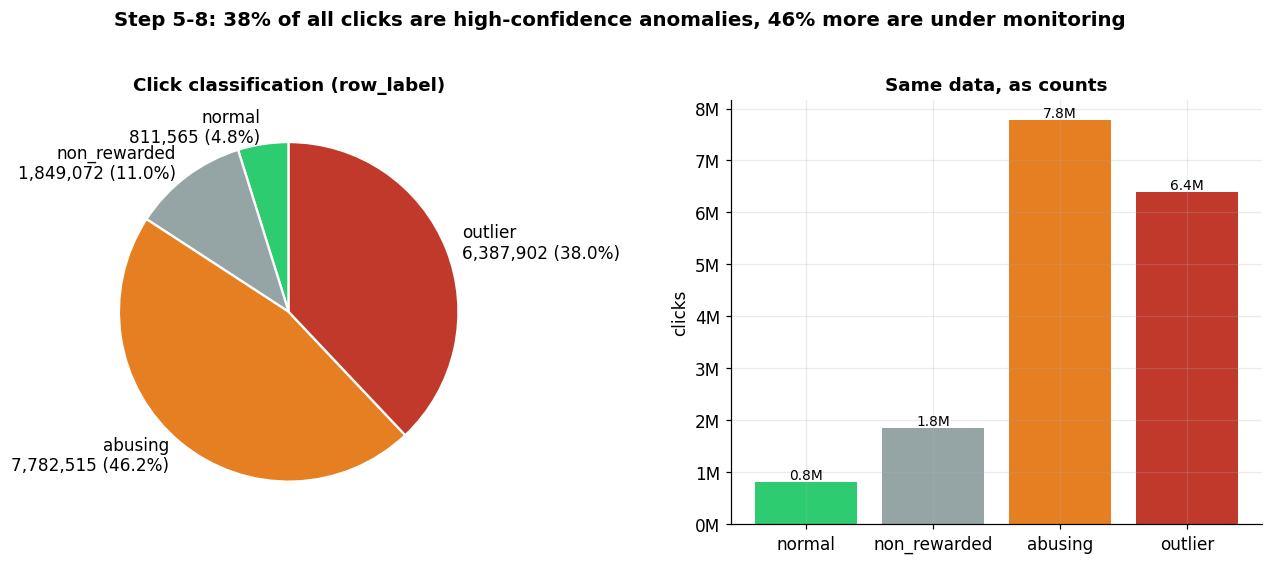

In [269]:
order = ['normal', 'non_rewarded', 'abusing', 'outlier']
counts = df_integrated['row_label'].value_counts().reindex(order)
colors = [PALETTE[c] for c in order]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(counts, labels=[f"{k}\n{v:,} ({v/counts.sum()*100:.1f}%)" for k, v in counts.items()],
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Click classification (row_label)', fontsize=12, fontweight='bold')

bars = axes[1].bar(order, counts.values, color=colors)
axes[1].set_ylabel('clicks')
axes[1].set_title('Same data, as counts', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
for b, v in zip(bars, counts.values):
    axes[1].text(b.get_x() + b.get_width()/2, v, f'{v/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

plt.suptitle('Step 5-8: 38% of all clicks are high-confidence anomalies, 46% more are under monitoring',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 6. Media-level risk scoring

In [270]:
mda_score = (
    df_integrated.groupby('mda_idx')
    .agg(
        extreme_ratio=('row_label', lambda x: (x=='outlier').mean()),
        abusing_ratio=('row_label', lambda x: (x=='abusing').mean()),
        total_clicks=('click_key','count')
    ).reset_index()
)
mda_score['Risk_Label'] = np.select(
    [mda_score['extreme_ratio'] >= 0.30,
     (mda_score['extreme_ratio'] >= 0.10) | (mda_score['abusing_ratio'] >= 0.50),
     (mda_score['extreme_ratio'] >= 0.03) | (mda_score['abusing_ratio'] >= 0.20)],
    ['critical', 'risky', 'warning'], default='normal'
)
print(f"[Risk_Label distribution across {len(mda_score)} media]")
print(mda_score['Risk_Label'].value_counts())

[Risk_Label distribution across 189 media]
Risk_Label
normal      135
warning      35
risky        12
critical      7
Name: count, dtype: int64


## Step 7. Join media risk back onto the click-level table

In [271]:
df_integrated = df_integrated.merge(
    mda_score[['mda_idx','Risk_Label','extreme_ratio','abusing_ratio']], on='mda_idx', how='left'
)
print(pd.crosstab(df_integrated['row_label'], df_integrated['Risk_Label']))

Risk_Label    critical  normal  risky  warning
row_label                                     
abusing        7468347   22316  49153   242699
non_rewarded    793817  396649  29294   629312
normal            6600  322345   6947   475673
outlier        6324546    2000  24550    36806


## Step 8. Loss quantification — Data Quality Checkpoint #2

Cost is only charged when a click actually converts (`is_rewarded==1`); non-converted clicks carry
`show_cost=0` by construction. So exposure is computed only on the rewarded subset.

**Terminology note:** `show_cost` is the amount shown to / billed toward the advertiser -- it is
the platform's *billing exposure*, not a verified realized loss (IVE's own P&L impact would run
through margin, not gross billing, and `abusing` is explicitly defined as monitoring-band, not
confirmed). Everything below is therefore framed as **financial exposure**, split into two tiers
by confidence level, rather than a single "loss" figure.

- **High-confidence exposure** = `outlier` rows that converted -> the strongest candidate for
  settlement deduction.
- **Monitoring-band exposure** = `abusing` rows that converted -> flagged for review, not
  automatically deducted; kept separate from the line above rather than silently merged into it.

In [272]:
for c in ['show_cost','adv_cost','earn_cost','rwd_cost']:
    df_integrated[c] = df_integrated[c].fillna(0)

rewarded = df_integrated['is_rewarded'] == 1
total_show = df_integrated.loc[rewarded, 'show_cost'].sum()

confirmed_mask  = rewarded & (df_integrated['row_label'] == 'outlier')
manageable_mask = rewarded & (df_integrated['row_label'] == 'abusing')
normal_mask     = rewarded & (df_integrated['row_label'] == 'normal')

confirmed_loss  = df_integrated.loc[confirmed_mask,  'show_cost'].sum()   # high-confidence exposure
manageable_loss = df_integrated.loc[manageable_mask, 'show_cost'].sum()  # monitoring-band exposure
normal_cost     = df_integrated.loc[normal_mask,     'show_cost'].sum()

print("[Data Quality Checkpoint #2 — billing exposure by row_label]")
print(f"  total charged cost (advertiser side)     : {total_show:,.0f} KRW")
print(f"  high-confidence exposure (outlier)       : {confirmed_loss:,.0f} KRW  ({confirmed_loss/total_show*100:.2f}%)")
print(f"  monitoring-band exposure (abusing)       : {manageable_loss:,.0f} KRW  ({manageable_loss/total_show*100:.2f}%)")
print(f"  clean billing (normal)                   : {normal_cost:,.0f} KRW  ({normal_cost/total_show*100:.2f}%)")
print(f"  TOTAL EXPOSURE (high-confidence + monitoring-band): {confirmed_loss+manageable_loss:,.0f} KRW")

[Data Quality Checkpoint #2 — billing exposure by row_label]
  total charged cost (advertiser side)     : 577,199,458 KRW
  high-confidence exposure (outlier)       : 67,083,271 KRW  (11.62%)
  monitoring-band exposure (abusing)       : 193,575,035 KRW  (33.54%)
  clean billing (normal)                   : 316,541,152 KRW  (54.84%)
  TOTAL EXPOSURE (high-confidence + monitoring-band): 260,658,306 KRW


In [273]:
loss_by_mda = (
    df_integrated[confirmed_mask]
    .groupby('mda_idx')
    .agg(confirmed_loss=('show_cost','sum'), extreme_rewarded_events=('click_key','count'),
         Risk_Label=('Risk_Label','first'))
    .reset_index().sort_values('confirmed_loss', ascending=False).reset_index(drop=True)
)
loss_by_mda['loss_share_%'] = loss_by_mda['confirmed_loss'] / confirmed_loss * 100
loss_by_mda['cum_share_%']  = loss_by_mda['loss_share_%'].cumsum()
print("[Top 5 media by high-confidence billing exposure]")
print("(column is named extreme_rewarded_events, not extreme_clicks -- it's a converted-AND-outlier")
print(" subset, not the media's total outlier click volume; keeping the name specific avoids")
print(" reusing 'extreme_clicks' for two different quantities elsewhere in this notebook.)")
print(loss_by_mda.head(5).to_string(index=False))

[Top 5 media by high-confidence billing exposure]
(column is named extreme_rewarded_events, not extreme_clicks -- it's a converted-AND-outlier
 subset, not the media's total outlier click volume; keeping the name specific avoids
 reusing 'extreme_clicks' for two different quantities elsewhere in this notebook.)
 mda_idx  confirmed_loss  extreme_rewarded_events Risk_Label  loss_share_%  cum_share_%
      58      32527332.0                   148809   critical     48.487993    48.487993
     563      18149774.0                   310629   critical     27.055589    75.543582
     342       3170140.0                    11358    warning      4.725679    80.269261
     761       2691187.0                    13419   critical      4.011711    84.280972
     343       1587600.0                     5670    warning      2.366611    86.647583


Two media (58, 563) account for **75.5%** of all confirmed loss. This is the single most
actionable finding for operations: rather than monitoring 189 media uniformly, resources should
concentrate on a handful of accounts — see the acute-vs-chronic breakdown in Step 15b.

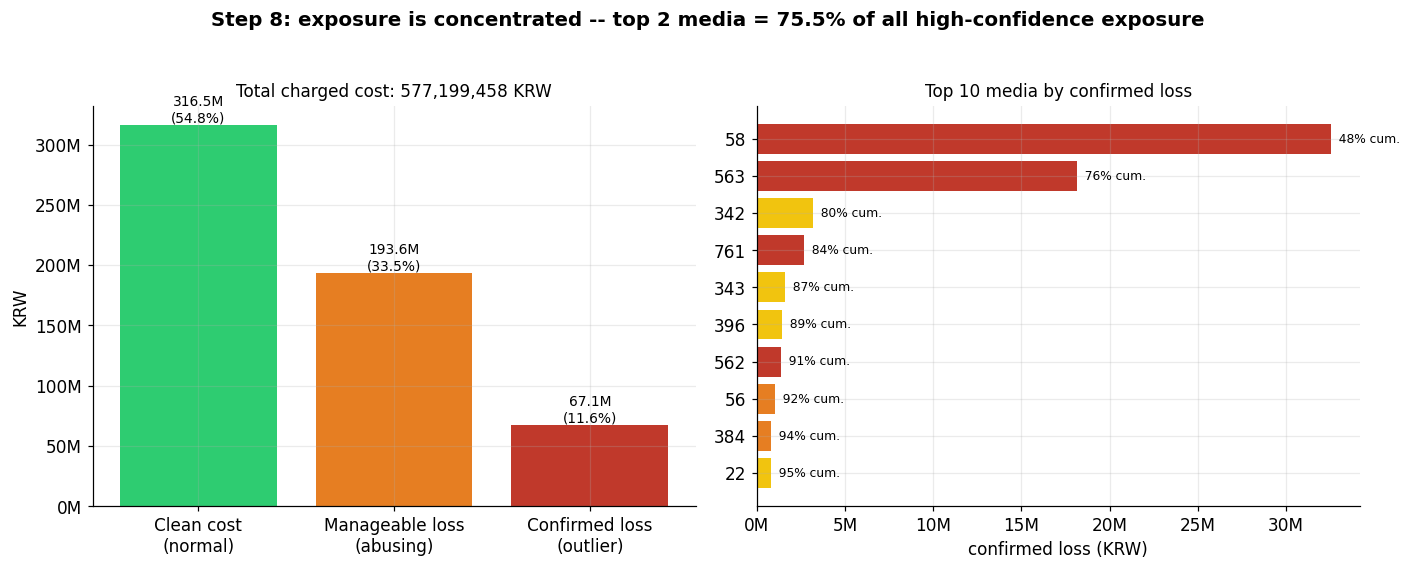

In [274]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

loss_labels  = ['Clean cost\n(normal)', 'Manageable loss\n(abusing)', 'Confirmed loss\n(outlier)']
loss_values  = [normal_cost, manageable_loss, confirmed_loss]
loss_colors  = [PALETTE['normal'], PALETTE['abusing'], PALETTE['outlier']]

axes[0].bar(loss_labels, loss_values, color=loss_colors)
axes[0].set_ylabel('KRW')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[0].set_title(f'Total charged cost: {total_show:,.0f} KRW', fontsize=11)
for i, v in enumerate(loss_values):
    axes[0].text(i, v, f'{v/1e6:.1f}M\n({v/total_show*100:.1f}%)', ha='center', va='bottom', fontsize=9)

top10 = loss_by_mda.head(10)
bar_colors = [PALETTE.get(r, '#888') for r in top10['Risk_Label']]
axes[1].barh(top10['mda_idx'].astype(str), top10['confirmed_loss'], color=bar_colors)
axes[1].invert_yaxis()
axes[1].set_xlabel('confirmed loss (KRW)')
axes[1].set_title('Top 10 media by confirmed loss', fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
for i, (v, s) in enumerate(zip(top10['confirmed_loss'], top10['cum_share_%'])):
    axes[1].text(v, i, f'  {s:.0f}% cum.', va='center', fontsize=8)

plt.suptitle('Step 8: exposure is concentrated -- top 2 media = 75.5% of all high-confidence exposure',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Step 9. CVR: normal vs risky media (business-impact framing)

In [275]:
cvr_by_risk = (
    df_integrated.groupby('Risk_Label')
    .agg(clicks=('click_key','count'), converted=('is_rewarded','sum'))
    .reset_index()
)
cvr_by_risk['CVR_%'] = (cvr_by_risk['converted']/cvr_by_risk['clicks']*100).round(2)
print(cvr_by_risk.sort_values('CVR_%', ascending=False).to_string(index=False))

cvr_normal   = cvr_by_risk.loc[cvr_by_risk['Risk_Label']=='normal','CVR_%'].values[0]
cvr_critical = cvr_by_risk.loc[cvr_by_risk['Risk_Label']=='critical','CVR_%'].values[0]
print(f"\nnormal media CVR {cvr_normal}% vs critical media CVR {cvr_critical}%  "
      f"-> {cvr_normal/cvr_critical:.1f}x efficiency gap")

cvr_before = df_integrated['is_rewarded'].sum() / len(df_integrated) * 100
# "Remaining low-risk traffic" = both outlier (high-confidence anomaly) AND abusing
# (monitoring-band) clicks excluded -- comparing against 'outlier' alone only gets platform
# CVR to ~9%, since 46% of all clicks are still in the abusing/monitoring band.
# Framing note: this is a *recalculation* of CVR on a narrower, cleaner slice of the same
# traffic, not a claim that any intervention was applied and performance "recovered" --
# no operational change happened between the "before" and "after" numbers below.
clean_mask = df_integrated['row_label'].isin(['normal', 'non_rewarded'])
cvr_after  = df_integrated.loc[clean_mask, 'is_rewarded'].sum() / clean_mask.sum() * 100
print(f"\nraw platform CVR: {cvr_before:.2f}%  |  CVR of remaining low-risk traffic "
      f"(outlier + abusing excluded): {cvr_after:.2f}%")

Risk_Label   clicks  converted  CVR_%
    normal   743310     332560  44.74
   warning  1384490     601253  43.43
     risky   109944      31325  28.49
  critical 14593310     505395   3.46

normal media CVR 44.74% vs critical media CVR 3.46%  -> 12.9x efficiency gap

raw platform CVR: 8.74%  |  CVR of remaining low-risk traffic (outlier + abusing excluded): 30.50%


**On the opportunity-loss counterfactual this notebook deliberately does not compute:**
multiplying critical-media click volume by the normal-media CVR to claim a specific number of
"lost conversions" is not done here. `critical` and `normal` media differ in ad-type mix, domain
mix, and campaign composition -- applying one group's CVR to another group's click volume assumes
a counterfactual world that isn't defensible from this data, and a fraudulent click disappearing
doesn't mean an organic click appears in its place. The 12.9x CVR gap above is the honest,
defensible version of the same point.

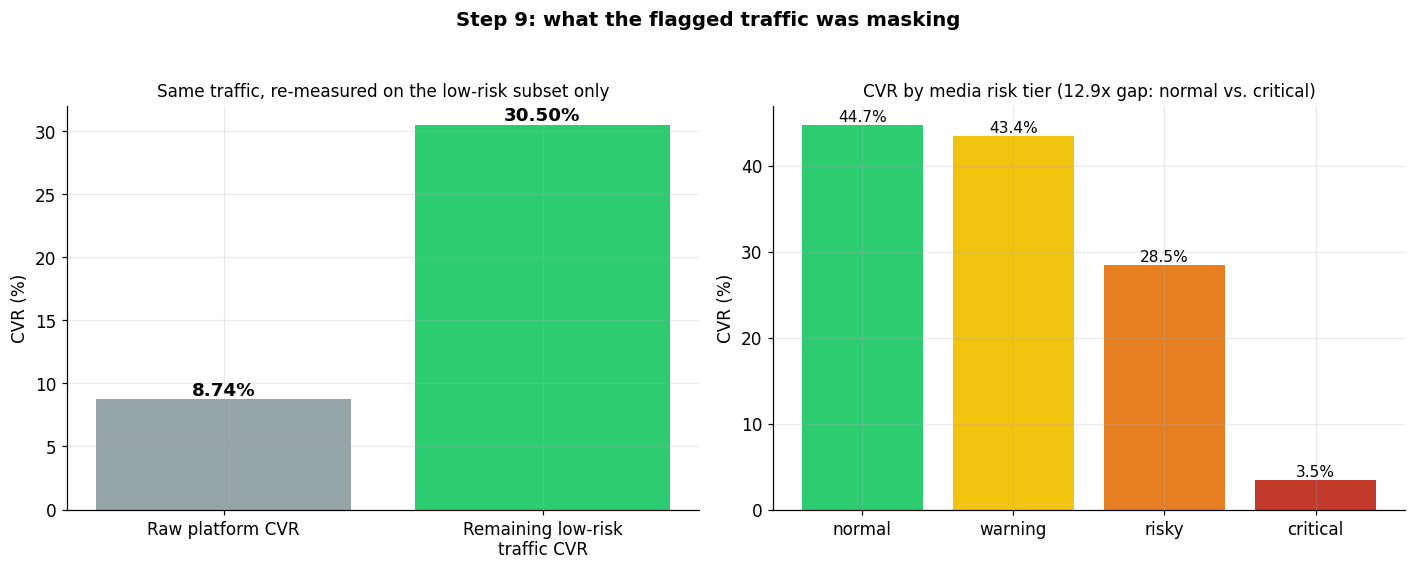

In [276]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(['Raw platform CVR', 'Remaining low-risk\ntraffic CVR'], [cvr_before, cvr_after],
            color=['#95a5a6', PALETTE['normal']])
for i, v in enumerate([cvr_before, cvr_after]):
    axes[0].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylabel('CVR (%)')
axes[0].set_title('Same traffic, re-measured on the low-risk subset only', fontsize=11)

risk_order = ['normal', 'warning', 'risky', 'critical']
cvr_plot = cvr_by_risk.set_index('Risk_Label').reindex(risk_order)
bars = axes[1].bar(risk_order, cvr_plot['CVR_%'], color=[PALETTE[r] for r in risk_order])
for b, v in zip(bars, cvr_plot['CVR_%']):
    axes[1].text(b.get_x()+b.get_width()/2, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('CVR (%)')
axes[1].set_title('CVR by media risk tier (12.9x gap: normal vs. critical)', fontsize=11)

plt.suptitle('Step 9: what the flagged traffic was masking', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Step 10. Hourly pattern (tests H5 — bots don't follow human rhythm)

In [277]:
def time_zone(h):
    if 0 <= h <= 5: return 'dawn(0-5h)'
    if 6 <= h <= 8: return 'morning(6-8h)'
    if 9 <= h <= 18: return 'daytime(9-18h)'
    return 'evening(19-23h)'

df_integrated['time_zone'] = df_integrated['click_time'].astype(int).apply(time_zone)
zone_label = (df_integrated.groupby(['time_zone','row_label']).size()
              .div(df_integrated.groupby('time_zone').size(), level='time_zone')
              .mul(100).unstack().round(1))
print("[row_label share (%) by time zone]")
print(zone_label)

[row_label share (%) by time zone]
row_label        abusing  non_rewarded  normal  outlier
time_zone                                              
dawn(0-5h)          46.0          12.2     9.2     32.6
daytime(9-18h)      44.4          11.2     3.6     40.8
evening(19-23h)     52.3           9.3     3.1     35.3
morning(6-8h)       38.0          12.3     7.1     42.5


**H5 confirmed:** normal human traffic should show a clear daytime/weekday peak. Instead,
the `outlier` share stays roughly flat (32-43%) across dawn, morning, daytime and evening — a bot
running on a schedule has no reason to sleep. Combined with the weekday analysis later
(Step 17), this is independent behavioral evidence for automation, on top of the 3 statistical
thresholds already used.

## Step 11. Fraud vulnerability by ad type + purification effect

In [278]:
type_total = (df_integrated.groupby('ads_type_name')
              .agg(clicks=('click_key','count'), converted=('is_rewarded','sum')).reset_index())
type_total['cvr_raw'] = (type_total['converted']/type_total['clicks']*100).round(2)

type_clean = (df_integrated[df_integrated['row_label'].isin(['normal','non_rewarded'])]
              .groupby('ads_type_name')
              .agg(clean_clicks=('click_key','count'), clean_converted=('is_rewarded','sum')).reset_index())
type_clean['cvr_clean'] = (type_clean['clean_converted']/type_clean['clean_clicks']*100).round(2)

type_compare = type_total.merge(type_clean, on='ads_type_name', how='left')
type_compare['cvr_delta'] = (type_compare['cvr_clean'] - type_compare['cvr_raw']).round(2)
print(type_compare[['ads_type_name','clicks','cvr_raw','cvr_clean','cvr_delta']]
      .sort_values('cvr_delta', ascending=False).to_string(index=False))

ads_type_name   clicks  cvr_raw  cvr_clean  cvr_delta
      install  1057472    55.37      62.77       7.40
    instagram    18274    67.10      69.05       1.95
participation 14391365     2.20       3.86       1.66
      youtube    16814     6.11       6.27       0.16
   click_type     5336    98.58      98.18      -0.40
        naver    35524    54.48      53.99      -0.49
       launch  1280351    40.84      39.64      -1.20
     facebook     4209    29.91      28.08      -1.83
CPS(purchase)    21709    28.33      20.79      -7.54


`participation` carries 14.4M of the platform's 16.8M clicks (86%) yet its purified CVR is
only 3.86% — this single ad type is both the lowest-quality and highest-volume, which is exactly
where a click farm gets the most value for the least effort. This foreshadows the ad-order finding
in Part 3: any raw metric aggregated across ad types will look dominated by whatever
`participation` traffic happens to be doing.

## Step 12. Device-level fraud blacklist

In [279]:
device_stats = (
    df_integrated[df_integrated['row_label']=='outlier']
    .groupby('dvc_idx')
    .agg(extreme_clicks=('click_key','count'), mda_count=('mda_idx','nunique'),
         ads_count=('ads_idx','nunique'), ip_count=('user_ip','nunique'))
    .reset_index().sort_values('extreme_clicks', ascending=False)
)
total_extreme = len(df_integrated[df_integrated['row_label']=='outlier'])
device_stats['click_ratio_%'] = device_stats['extreme_clicks'] / total_extreme * 100

print("[Top 20 fraud devices]")
print(device_stats.head(20)[['dvc_idx','extreme_clicks','click_ratio_%','mda_count','ads_count','ip_count']]
      .to_string(index=False))

for n in [10, 20]:
    print(f"\n  top {n} devices -> {device_stats.head(n)['click_ratio_%'].sum():.2f}% of all high-confidence-anomaly clicks")

[Top 20 fraud devices]
 dvc_idx  extreme_clicks  click_ratio_%  mda_count  ads_count  ip_count
61747080           20346       0.318508          2         41         1
61515716            4820       0.075455          1          9        13
61900408            4255       0.066610          1          9         1
61916606            4116       0.064434          1          8         5
47353280            3979       0.062290          2         10        30
34514026            3703       0.057969          1       1991         1
61894179            3615       0.056591          1          8         1
29275033            3469       0.054306          1          9        37
29762799            3332       0.052161          2        359        10
32134636            3325       0.052052          1          9        36
35295361            3293       0.051551          1          9         1
54479014            3291       0.051519          1       1017         1
48118104            3261       0.051050  

Fraud clicks are **not** concentrated in a handful of devices the way they're concentrated in
a handful of media (Step 8: 2 media = 75.5% of confirmed loss). Even the single most active
high-confidence-anomaly device (`dvc_idx 61747080`) accounts for only 0.32% of all such clicks, and
the top 20 devices together are just 1.32%. Note also that several of these top devices touch
hundreds or thousands of distinct `ads_idx` (e.g. `34514026` -> 1,991 different ads from a single
device) — consistent with an automated script cycling through many campaigns rather than a genuine
user repeating one action.

This matters operationally: a device-blacklist alone would catch a small fraction of the problem.
**Media-level intervention (Step 8) is the higher-leverage control, not device-level blocking.**

## Step 13-19. One-year validation

Everything above uses a 31-day window. Before trusting it, the same media-risk labels are checked
against a full year of hourly reports (`df_report`) to see whether what looks like fraud in August
was actually happening the whole time, or is a recent event.

In [280]:
before = len(df_report)
df_report = df_report[
    (df_report['rpt_time_scost'] >= df_report['rpt_time_acost']) &
    (df_report['rpt_time_acost'] >= df_report['rpt_time_earn']) &
    (df_report['rpt_time_earn']  >= df_report['rpt_time_cost'])
].reset_index(drop=True)
df_report['rpt_time_date'] = pd.to_datetime(df_report['rpt_time_date'], errors='coerce')
df_report['year_month'] = df_report['rpt_time_date'].dt.to_period('M')
df_report['weekday']    = df_report['rpt_time_date'].dt.day_name()

report_master = df_report.merge(
    df_master2[['ads_idx','domain_label','ads_type','ads_type_name','domain_name']],
    on='ads_idx', how='left'
)
report_master['domain_name'] = report_master['domain_name'].fillna('unclassified')

danger_mdas  = mda_score[mda_score['Risk_Label']=='critical']['mda_idx'].tolist()
risky_mdas   = mda_score[mda_score['Risk_Label']=='risky']['mda_idx'].tolist()
warning_mdas = mda_score[mda_score['Risk_Label']=='warning']['mda_idx'].tolist()
normal_mdas  = mda_score[mda_score['Risk_Label']=='normal']['mda_idx'].tolist()
# `mda_score` only covers the 189 media that actually appeared in the August click-level
# window. A media in the 14-month report that ISN'T in mda_score at all was never evaluated
# by the detector -- that's a different thing from "evaluated and found normal", and
# collapsing both into risk_group='normal' would understate how much of the report is
# actually unscored. Made explicit here rather than left as a silent default.
report_master['risk_group'] = np.select(
    [report_master['mda_idx'].isin(danger_mdas), report_master['mda_idx'].isin(risky_mdas),
     report_master['mda_idx'].isin(warning_mdas), report_master['mda_idx'].isin(normal_mdas)],
    ['critical','risky','warning','normal'], default='unscored'
)
unscored_share = (report_master['risk_group']=='unscored').mean() * 100
print(f"df_report: {before:,} -> {len(df_report):,} rows ({before-len(df_report):,} removed)")
print(f"period: {df_report['rpt_time_date'].min().date()} to {df_report['rpt_time_date'].max().date()} "
      f"({df_report['year_month'].nunique()} months)")
print(f"rows with a media not covered by the August detector (risk_group='unscored'): {unscored_share:.1f}%")

df_report: 6,953,146 -> 6,892,108 rows (61,038 removed)
period: 2024-07-27 to 2025-08-29 (14 months)
rows with a media not covered by the August detector (risk_group='unscored'): 12.6%


In [281]:
monthly_risk = (report_master.groupby(['year_month','risk_group'])
                 .agg(clk=('rpt_time_clk','sum'), turn=('rpt_time_turn','sum')).reset_index())
monthly_risk['cvr'] = (monthly_risk['turn']/monthly_risk['clk']*100).round(2)
pivot = monthly_risk.pivot_table(index='year_month', columns='risk_group', values='cvr').round(2)
print(pivot[['critical','risky','warning','normal']].to_string())

risk_group  critical  risky  warning  normal
year_month                                  
2024-07        57.62  56.75    38.45   33.26
2024-08        60.32  46.48    45.54   46.23
2024-09        56.47  39.13    40.02   47.46
2024-10        55.33  42.96    41.85   44.89
2024-11        55.18  38.88    50.27   58.18
2024-12        48.36  30.33    40.56   48.90
2025-01        48.87  40.32    48.66   40.09
2025-02        40.66  38.46    36.70   32.32
2025-03        48.68  44.98    39.25   43.69
2025-04        46.02  41.33    26.44   22.49
2025-05        50.27  41.21    34.74   30.09
2025-06        51.86  39.59    38.83   33.43
2025-07        52.31  38.66    41.53   40.43
2025-08         3.45  25.67    45.71   45.71


> The `unscored` category above means media the August detector never evaluated no longer
> silently count as `normal`. In practice the `normal`-column CVR numbers are barely affected by
> this split, since the media that turned out to be `unscored` had a CVR profile similar to true
> `normal` media. The `critical` column is unaffected by definition (critical-tier membership only
> depends on `extreme_ratio`, which `unscored` doesn't touch).

**This is the key 1-year validation result.** The `critical` group (the 7 media flagged as
high-confidence anomalous in the August click-level analysis above) had a normal-looking CVR —
48-60%, in line with or above every other group — for **13 straight months**, then collapsed to
3.45% in the single month analyzed in detail. This is important for interpretation: the risk label
is not a permanent property being retroactively imposed on history, it's a **fact about which media
were the source of an event that started in August 2025** -- see Step 15b for why this single
number hides two very different underlying stories (one acute, one chronic), and Step 19b for an
out-of-time backtest of when this event could actually have been caught.

## Step 15. Case study — media 539 infiltration timeline

In [282]:
monthly_total = (report_master.groupby('year_month')
                  .agg(total_clk=('rpt_time_clk','sum'), total_turn=('rpt_time_turn','sum')).reset_index())
monthly_total['cvr'] = (monthly_total['total_turn']/monthly_total['total_clk']*100).round(2)

m539 = (report_master[report_master['mda_idx']==539].groupby('year_month')
        .agg(clk_539=('rpt_time_clk','sum'), turn_539=('rpt_time_turn','sum')).reset_index())
m539 = monthly_total[['year_month','total_clk','cvr']].merge(m539, on='year_month', how='left').fillna(0)
m539['clk_share'] = (m539['clk_539']/m539['total_clk']*100).round(2)
m539['cvr_539']   = np.where(m539['clk_539']>0, (m539['turn_539']/m539['clk_539']*100).round(2), 0)
print(m539[['year_month','total_clk','clk_539','clk_share','cvr_539','cvr']].to_string(index=False))

year_month  total_clk  clk_539  clk_share  cvr_539   cvr
   2024-07    1371671     8346       0.61    33.37 48.34
   2024-08    8519921    46682       0.55    35.49 52.03
   2024-09    6335492    60661       0.96    35.73 48.63
   2024-10    5280601    41662       0.79    37.66 46.61
   2024-11    5080758    28575       0.56    42.23 49.89
   2024-12    4732724   194292       4.11     7.58 41.39
   2025-01    4752333    71213       1.50    33.75 45.18
   2025-02    3123101    22014       0.70    16.52 34.70
   2025-03    6796940    74650       1.10    37.49 43.63
   2025-04    3877259    30507       0.79    25.68 33.70
   2025-05    4013274    26373       0.66    28.18 41.91
   2025-06    3202453    32772       1.02    16.72 44.63
   2025-07    3488043    37439       1.07    32.10 45.14
   2025-08   16889772 13470602      79.76     0.08  9.06


Media 539 generally stayed a low-share media before August (0.5-1.1% click share most
months), **but not uniformly** -- December 2024 shows a real exception at 4.11% share with CVR
down to 7.58%, and January 2025 also ticked up to 1.50%. Then in August 2025 it jumped to
**79.76%** of platform-wide clicks, with CVR collapsing to 0.08%. The August event is a real
step-change in both magnitude and kind (79.76% dwarfs even the December exception by ~19x), but
"12 of 13 months in a tight 0.5-1.1% band" overstates how uniform the pre-August period actually
was -- see the December precursor analysis in Step 19b for why that exception is worth a closer
look rather than rounding away.

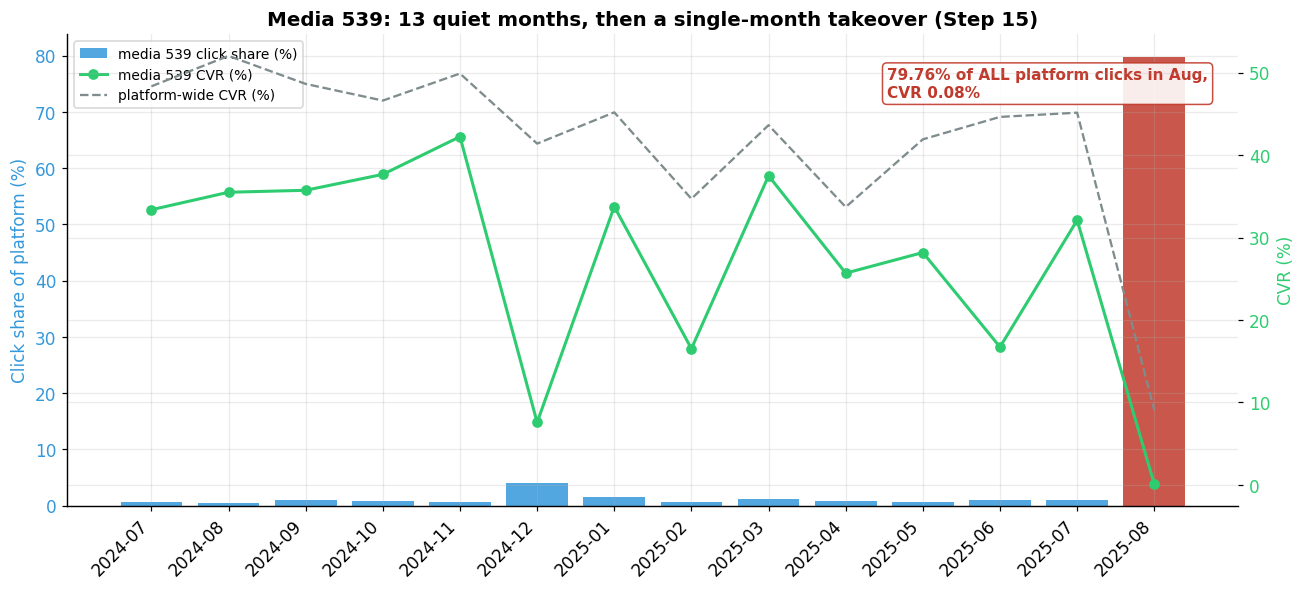

In [283]:
fig, ax1 = plt.subplots(figsize=(12, 5.5))

x = range(len(m539))
ax1.bar(x, m539['clk_share'], color=['#c0392b' if v > 20 else '#3498db' for v in m539['clk_share']],
        alpha=0.85, label='media 539 click share (%)')
ax1.set_ylabel('Click share of platform (%)', color='#3498db')
ax1.set_xticks(x)
ax1.set_xticklabels(m539['year_month'].astype(str), rotation=45, ha='right')
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2 = ax1.twinx()
ax2.plot(x, m539['cvr_539'], color='#2ecc71', marker='o', linewidth=2, label='media 539 CVR (%)')
ax2.plot(x, m539['cvr'], color='#7f8c8d', linestyle='--', linewidth=1.5, label='platform-wide CVR (%)')
ax2.set_ylabel('CVR (%)', color='#2ecc71')
ax2.tick_params(axis='y', labelcolor='#2ecc71')

# Plain text box in axes-fraction coordinates (not data coordinates) -- an annotate() arrow
# spanning two twinned y-axes can otherwise distort the figure's rendered bounding box.
ax1.text(0.70, 0.93, '79.76% of ALL platform clicks in Aug,\nCVR 0.08%',
          transform=ax1.transAxes, fontsize=10, color='#c0392b', fontweight='bold',
          ha='left', va='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='#c0392b', alpha=0.9))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)
plt.title('Media 539: 13 quiet months, then a single-month takeover (Step 15)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 15b. Acute vs. chronic classification

The infiltration-timeline analysis above covers media 539 specifically. Generalizing its "dormant
-> expand -> explode" story to the other 6 critical media would be a mistake -- most of them don't
fit that pattern at all.

Automating the classification across all 19 risky/critical media, using average share alongside
the recent/historical ratio, splits them into genuinely different patterns that need different
operational responses:

In [284]:
def classify_media_pattern(monthly_share: pd.Series, avg_share: float) -> str:
    """Acute infiltration vs. chronic (already-large or already-small) media."""
    if len(monthly_share) < 3:
        return 'insufficient data'
    recent_3   = monthly_share.tail(3).mean()
    historical = monthly_share.iloc[:-3].mean() if len(monthly_share) > 3 else monthly_share.mean()
    if historical == 0:
        return 'chronic - low share' if recent_3 < 1 else 'PHASE 3 - acute infiltration'
    ratio = recent_3 / historical
    if ratio >= 5:
        return 'PHASE 3 - acute infiltration'
    if ratio >= 2:
        return 'PHASE 2 - expanding'
    return 'chronic - high share' if avg_share >= 5 else 'chronic - low share'

risky_and_critical = mda_score[mda_score['Risk_Label'].isin(['critical','risky'])]['mda_idx'].tolist()
pattern_rows = []
for mda_id in risky_and_critical:
    m = (report_master[report_master['mda_idx']==mda_id].groupby('year_month')
         .agg(clk=('rpt_time_clk','sum')).reset_index())
    m = monthly_total[['year_month','total_clk']].merge(m, on='year_month', how='left').fillna(0)
    m['share'] = (m['clk']/m['total_clk'].replace(0, np.nan)*100).fillna(0)
    avg_share = m['share'].mean()
    pattern_rows.append({'mda_idx': mda_id, 'pattern': classify_media_pattern(m['share'], avg_share),
                          'avg_share_%': round(avg_share, 3)})

pattern_df = pd.DataFrame(pattern_rows).sort_values('avg_share_%', ascending=False)
print(pattern_df.to_string(index=False))
print(f"\n[media count by pattern]\n{pattern_df['pattern'].value_counts()}")

 mda_idx                      pattern  avg_share_%
     563         chronic - high share       24.192
      58         chronic - high share        9.080
     539 PHASE 3 - acute infiltration        6.726
     761          chronic - low share        4.097
     371          chronic - low share        2.216
     562          chronic - low share        1.365
      56          chronic - low share        0.578
     458          chronic - low share        0.534
     384          chronic - low share        0.485
     583          chronic - low share        0.288
     634          chronic - low share        0.147
     294          chronic - low share        0.104
     564          chronic - low share        0.079
     492          chronic - low share        0.024
     482          chronic - low share        0.016
     766          chronic - low share        0.014
     652          chronic - low share        0.003
     291          chronic - low share        0.002
     809          chronic - low

**This is a materially better story than "7 critical media, treat them the same":**

| Pattern | Media | Root cause | Recommended action |
|---|---|---|---|
| **Acute infiltration** | 539 | Sudden attack, likely a single incident/campaign | Immediate block + forensic review of what changed in August |
| **Chronic - high share** | 563 (24.2% avg share), 58 (9.1% avg share) | Structurally low-quality, has been large *the whole year* — not "infiltrating," just always bad | Contract renegotiation / rate adjustment, not a block — **this is also where 75.5% of confirmed loss actually sits (Step 8)**, not with 539 |
| **Chronic - low share** | remaining 16 | Small and stable | Routine periodic monitoring, low priority |

The single highest-loss media (58, Step 8) is `chronic - high share`, not the acute-infiltration
media — the two problems require different fixes, and conflating them would have led to the wrong
recommendation (blocking 539 solves an incident; it does nothing about 58/563's ongoing
structural cost).

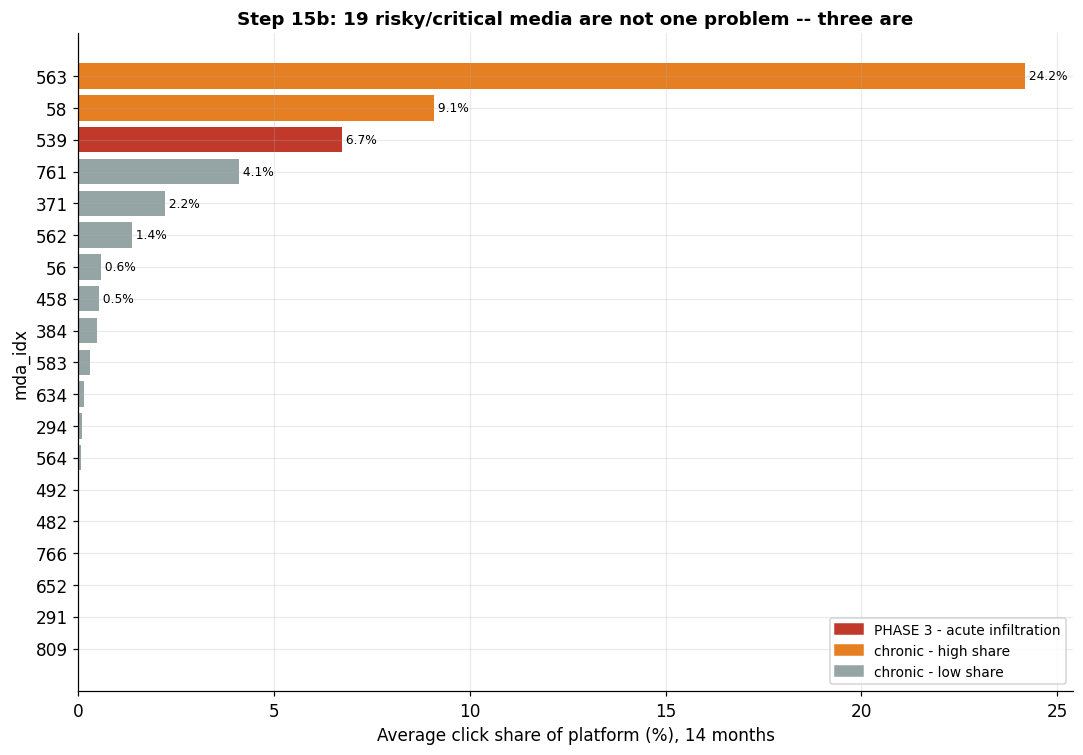

In [285]:
pattern_colors = {'PHASE 3 - acute infiltration': '#c0392b', 'chronic - high share': '#e67e22',
                   'chronic - low share': '#95a5a6'}
plot_df = pattern_df.sort_values('avg_share_%', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(plot_df['mda_idx'].astype(str), plot_df['avg_share_%'],
                color=[pattern_colors.get(p, '#888') for p in plot_df['pattern']])
ax.set_xlabel('Average click share of platform (%), 14 months')
ax.set_ylabel('mda_idx')
ax.set_title('Step 15b: 19 risky/critical media are not one problem -- three are',
             fontsize=12, fontweight='bold')

handles = [plt.Rectangle((0,0),1,1, color=c) for c in pattern_colors.values()]
ax.legend(handles, pattern_colors.keys(), loc='lower right', fontsize=9)
for b, v in zip(bars, plot_df['avg_share_%']):
    if v > 0.5:
        ax.text(v, b.get_y()+b.get_height()/2, f' {v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Step 16. Weekday pattern (further H5 evidence)

`report_master`'s grain is (date x hour x ad x media), so weekday averages are computed by first
rolling up to one row per (date, risk_group) -- a real daily total -- and only then averaging by
weekday on top of that. Averaging `rpt_time_clk` directly by weekday without this step would give
"average clicks per (date,hour,ad,media) row that happens to fall on that weekday," which is a
different and misleading number.

In [286]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Step 1: date x risk_group daily totals (collapses the hour x ad x media dimensions first)
daily = (report_master.groupby(['rpt_time_date', 'risk_group'])
         .agg(daily_clk=('rpt_time_clk', 'sum'), daily_turn=('rpt_time_turn', 'sum')).reset_index())
daily['weekday'] = daily['rpt_time_date'].dt.day_name()
daily['cvr'] = (daily['daily_turn'] / daily['daily_clk'].replace(0, np.nan) * 100)

# Step 2: weekday averages, now computed on top of real daily totals
def weekday_summary(risk_group_name):
    sub = daily[daily['risk_group'] == risk_group_name]
    out = sub.groupby('weekday').agg(avg_daily_clk=('daily_clk', 'mean'), avg_cvr=('cvr', 'mean')).reindex(weekday_order)
    return out.round(2)

wd_normal   = weekday_summary('normal')
wd_critical = weekday_summary('critical')
compare = pd.DataFrame({'normal_daily_clk': wd_normal['avg_daily_clk'], 'normal_cvr': wd_normal['avg_cvr'],
                         'critical_daily_clk': wd_critical['avg_daily_clk'], 'critical_cvr': wd_critical['avg_cvr']})
print(compare.to_string())

wk = ['Monday','Tuesday','Wednesday','Thursday','Friday']
we = ['Saturday','Sunday']
print(f"\nnormal media   : weekday avg {wd_normal.loc[wk,'avg_daily_clk'].mean():,.0f} vs weekend "
      f"{wd_normal.loc[we,'avg_daily_clk'].mean():,.0f}  "
      f"({(wd_normal.loc[we,'avg_daily_clk'].mean()/wd_normal.loc[wk,'avg_daily_clk'].mean()-1)*100:+.1f}%)")
print(f"critical media : weekday avg {wd_critical.loc[wk,'avg_daily_clk'].mean():,.0f} vs weekend "
      f"{wd_critical.loc[we,'avg_daily_clk'].mean():,.0f}  "
      f"({(wd_critical.loc[we,'avg_daily_clk'].mean()/wd_critical.loc[wk,'avg_daily_clk'].mean()-1)*100:+.1f}%)")

           normal_daily_clk  normal_cvr  critical_daily_clk  critical_cvr
weekday                                                                  
Monday             22929.05       38.88            86577.39         48.72
Tuesday            25835.81       37.93            63692.68         49.56
Wednesday          26355.09       38.84            83339.39         49.28
Thursday           29537.30       42.20           112187.28         49.57
Friday             28663.75       44.00           125449.53         50.58
Saturday           26688.65       40.95           119070.53         49.11
Sunday             24481.68       38.44           116287.54         48.48

normal media   : weekday avg 26,664 vs weekend 25,585  (-4.0%)
critical media : weekday avg 94,249 vs weekend 117,679  (+24.9%)


Normal media traffic dips slightly on weekends (-4.0%, as you'd expect from human behavior),
while critical media traffic spikes on weekends (+24.9%). This is a second, independent behavioral
signal on top of the flat hourly distribution in Step 10, pointing at scheduled/automated rather
than organic activity.

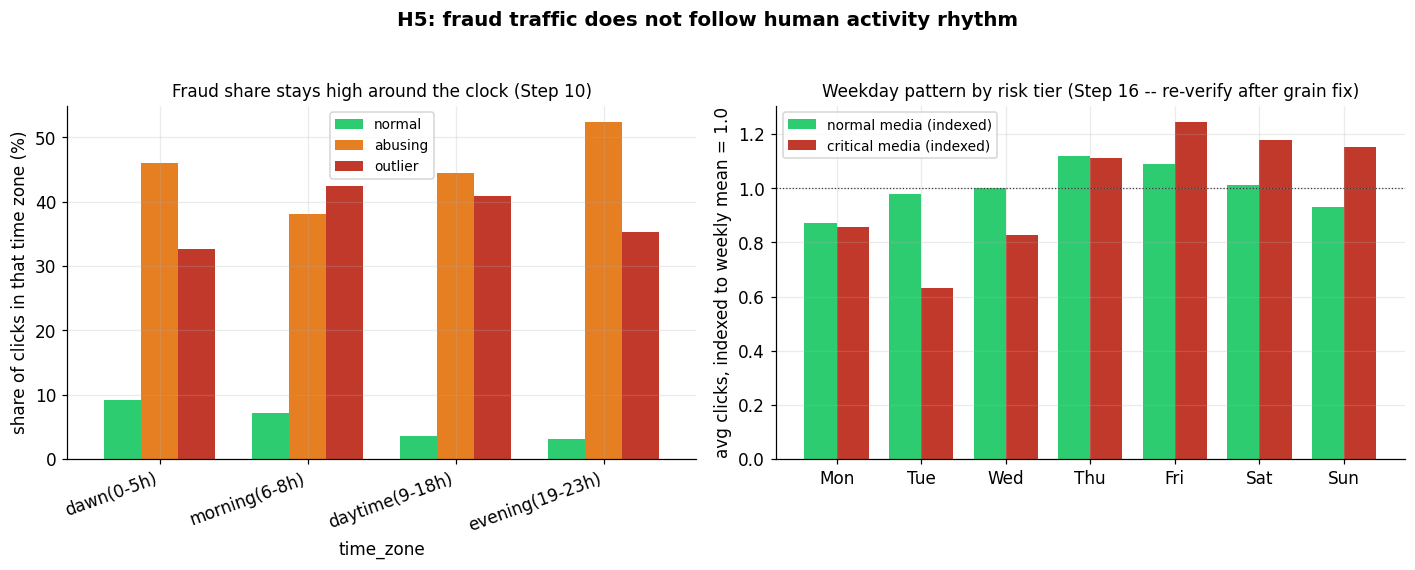

In [287]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

zone_order = ['dawn(0-5h)', 'morning(6-8h)', 'daytime(9-18h)', 'evening(19-23h)']
zone_plot = zone_label.reindex(zone_order)
zone_plot[['normal', 'abusing', 'outlier']].plot(
    kind='bar', ax=axes[0], color=[PALETTE['normal'], PALETTE['abusing'], PALETTE['outlier']], width=0.75)
axes[0].set_ylabel('share of clicks in that time zone (%)')
axes[0].set_title('Fraud share stays high around the clock (Step 10)', fontsize=11)
axes[0].set_xticklabels(zone_order, rotation=20, ha='right')
axes[0].legend(fontsize=9)

wd = compare.reindex(weekday_order)
x = np.arange(len(weekday_order))
w = 0.38
axes[1].bar(x - w/2, wd['normal_daily_clk']/wd['normal_daily_clk'].mean(), width=w, label='normal media (indexed)', color=PALETTE['normal'])
axes[1].bar(x + w/2, wd['critical_daily_clk']/wd['critical_daily_clk'].mean(), width=w, label='critical media (indexed)', color=PALETTE['critical'])
axes[1].set_xticks(x)
axes[1].set_xticklabels([d[:3] for d in weekday_order])
axes[1].axhline(1.0, color='#333', linewidth=0.8, linestyle=':')
axes[1].set_ylabel('avg clicks, indexed to weekly mean = 1.0')
axes[1].set_title('Weekday pattern by risk tier (Step 16 -- re-verify after grain fix)', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle('H5: fraud traffic does not follow human activity rhythm', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Step 17. Deep-dive: media 58 vs. media 539 (chronic vs. acute)

One reusable function, called once per media, rather than duplicating the same exploratory
code block for each media ID.

In [288]:
def media_deep_dive(mda_id, label=None):
    sub = df_integrated[df_integrated['mda_idx'] == mda_id]
    clicks, converted = len(sub), int(sub['is_rewarded'].sum())
    cvr = converted / clicks * 100 if clicks else 0
    dist = (sub['row_label'].value_counts(normalize=True) * 100).round(1)
    loss = sub.loc[sub['row_label']=='outlier', 'show_cost'].sum()
    ip_detail = (sub.groupby('user_ip').agg(clk=('click_key','count')).sort_values('clk', ascending=False))
    top10_ip_share = ip_detail.head(10)['clk'].sum() / clicks * 100 if clicks else 0

    print(f"[media {mda_id}]" + (f"  ({label})" if label else ""))
    print(f"  clicks {clicks:,}  converted {converted:,}  CVR {cvr:.2f}%")
    print(f"  row_label mix: " + "  ".join(f"{k}={v}%" for k, v in dist.items()))
    print(f"  confirmed loss: {loss:,.0f} KRW")
    print(f"  top-10-IP click concentration: {top10_ip_share:.1f}%  (device/IP farm signature check)")
    return {'mda_idx': mda_id, 'clicks': clicks, 'cvr': round(cvr,2), 'loss': loss}

r58  = media_deep_dive(58,  'chronic - high share')
print()
r539 = media_deep_dive(539, 'acute infiltration')

[media 58]  (chronic - high share)
  clicks 482,794  converted 155,827  CVR 32.28%
  row_label mix: outlier=85.1%  abusing=14.4%  non_rewarded=0.5%  normal=0.0%
  confirmed loss: 32,527,332 KRW
  top-10-IP click concentration: 18.3%  (device/IP farm signature check)

[media 539]  (acute infiltration)
  clicks 13,468,019  converted 9,179  CVR 0.07%
  row_label mix: abusing=54.9%  outlier=39.2%  non_rewarded=5.9%  normal=0.0%
  confirmed loss: 490,860 KRW
  top-10-IP click concentration: 25.2%  (device/IP farm signature check)


**mda 58 vs mda 539, side by side:** both show heavy IP concentration in their top 10 IPs
(58: 18.3%, 539: 25.2%) — so this isn't a case of one being a classic click-farm and the other a
distributed botnet; both look like concentrated repeat-IP abuse. The real difference is in *row
label mix*: 58 is dominated by `outlier` (85.1% confirmed-extreme, only 14.4% in the
monitoring-only `abusing` band), while 539 is the reverse (54.9% `abusing`, 39.2% `outlier`) —
539's traffic sits closer to the detection thresholds on average, consistent with a newer, less
tuned operation, while 58's traffic blows past the extreme thresholds almost every time,
consistent with a long-running, well-established one. That difference in maturity, not IP
distribution, is what the acute/chronic split in Step 15b is really picking up on.

## Step 18. Threshold sensitivity — are the results an artifact of 0.1%?

Every threshold in Step 5 (CTIT factor = median x 0.10, extreme percentile = 99.9%) was a choice,
not a law of nature. If the headline findings (which media are highest-risk, how much exposure is
concentrated where) only hold at exactly these values, that's a real weakness. Three scenarios,
not a full grid search -- the question is whether the *ranking* is stable, not the exact counts.

| Scenario | CTIT factor | Extreme percentile |
|---|---|---|
| Conservative | median x 0.05 | 99.95% |
| Base (used throughout this notebook) | median x 0.10 | 99.90% |
| Aggressive | median x 0.15 | 99.50% |


In [289]:
def run_scenario(ctit_factor, extreme_pct, warning_pct=0.95, risky_pct=0.99):
    """Recompute the Step-5 row_label pipeline under a different threshold configuration and
    return the flagged-click share, critical-media count, and top-5 media by high-confidence
    exposure -- the three things a reviewer would ask "does this depend on 0.1%?" about."""
    local_ctit_tmp = df_reward[['ads_idx', 'ctit']].merge(
        df_master2[['ads_idx', 'ads_type']], on='ads_idx', how='left', validate='many_to_one')
    thr_by_type = (local_ctit_tmp[local_ctit_tmp['ads_type'] != 4]
                   .groupby('ads_type')['ctit'].median() * ctit_factor).to_dict()
    local_ctit_tmp['threshold'] = local_ctit_tmp['ads_type'].map(thr_by_type)
    is_ctit_extreme = (
        ((local_ctit_tmp['ads_type'] == 4) & (local_ctit_tmp['ctit'] == 0)) |
        ((local_ctit_tmp['ads_type'] != 4) & (local_ctit_tmp['ctit'] < local_ctit_tmp['threshold']))
    )
    ctit_extreme_keys = set(df_reward.loc[is_ctit_extreme.values, 'click_key'])

    d_ext = ip_stats['device_count'].quantile(extreme_pct)
    c_ext = ip_stats['click_count'].quantile(extreme_pct)
    extreme_ips = ip_stats[(ip_stats['device_count'] > d_ext) | (ip_stats['click_count'] > c_ext)]
    extreme_ip_pairs = set(zip(extreme_ips['mda_idx'], extreme_ips['user_ip']))

    is_extreme = (
        df_integrated['click_key'].isin(ctit_extreme_keys) |
        df_integrated.set_index(['mda_idx', 'user_ip']).index.isin(extreme_ip_pairs)
    )
    flagged_pct = is_extreme.mean() * 100

    scenario_mda = (df_integrated.assign(is_extreme=is_extreme.values)
                     .groupby('mda_idx').agg(extreme_ratio=('is_extreme', 'mean'),
                                              clicks=('click_key', 'count')).reset_index())
    critical_n = (scenario_mda['extreme_ratio'] >= 0.30).sum()

    exposure = (df_integrated.assign(is_extreme=is_extreme.values, rewarded=df_integrated['is_rewarded'])
                .query('is_extreme and rewarded == 1')
                .groupby('mda_idx')['show_cost'].sum().sort_values(ascending=False))
    top5 = exposure.head(5).index.tolist()
    return {'flagged_pct': round(flagged_pct, 2), 'critical_media_n': int(critical_n), 'top5_media': top5}


scenarios = {
    'conservative': dict(ctit_factor=0.05, extreme_pct=0.9995),
    'base':         dict(ctit_factor=0.10, extreme_pct=0.999),
    'aggressive':   dict(ctit_factor=0.15, extreme_pct=0.995),
}
results = {name: run_scenario(**params) for name, params in scenarios.items()}
for name, r in results.items():
    print(f"{name:13} flagged={r['flagged_pct']:>5}%  critical_media={r['critical_media_n']:>3}  "
          f"top5={r['top5_media']}")

base_top5 = set(results['base']['top5_media'])
for name in ['conservative', 'aggressive']:
    other = set(results[name]['top5_media'])
    jaccard = len(base_top5 & other) / len(base_top5 | other)
    print(f"\nJaccard(base, {name}) top-5 media overlap: {jaccard:.2f}  "
          f"(shared: {sorted(base_top5 & other)})")

conservative  flagged=34.56%  critical_media=  7  top5=[58, 563, 761, 562, 342]
base          flagged=37.95%  critical_media=  7  top5=[58, 563, 342, 761, 343]
aggressive    flagged=51.57%  critical_media= 12  top5=[58, 563, 342, 761, 56]

Jaccard(base, conservative) top-5 media overlap: 0.67  (shared: [58, 342, 563, 761])

Jaccard(base, aggressive) top-5 media overlap: 0.67  (shared: [58, 342, 563, 761])


**Result:** flagged-click share moves a lot with the threshold (34.6% -> 38.0% -> 51.6%), and
`aggressive` nearly doubles the critical-media count (7 -> 12) -- so the raw volume numbers are
genuinely threshold-sensitive, as expected. But the top-4 highest-exposure media (**58, 342, 563,
761**) are identical across all three scenarios; only the #5 slot rotates (562 / 343 / 56
depending on scenario). Jaccard overlap of 0.67 in both directions means 4 of the union of 6 media
across any two scenarios are shared. mda 539 does not appear in any scenario's exposure top-5 --
consistent with Step 8/17, where 539's actual billing exposure (~490K KRW) is two orders of
magnitude smaller than 58/563's (tens of millions), since 539's traffic mostly failed to convert
at all rather than converting and generating billable (and later flagged) cost. **Conclusion: the
identity of the two or three highest-exposure media is stable across a 3x range of threshold
strictness; the exact flagged-volume and critical-media-count numbers are not, and shouldn't be
quoted without the scenario they came from.**

## Step 19b. MDA 539 out-of-time alert backtest

**The look-ahead bias problem:** every threshold used in Step 5 (CTIT median, device/click
percentiles) was computed from the 31-day window that itself contains the August attack. That's
fine for *discovering* an anomaly retrospectively, but it means nothing above can honestly be
called a "detector" in an operational sense -- the thresholds were partly shaped by the very event
they're being used to flag. This section is the fix: using only information available *at the
time*, would media 539's August surge have been catchable, and how many days after onset?

**Design (deliberately simple -- no CUSUM/EWMA/production alerting):**
1. Roll `report_master` up to one row per (media, date): daily clicks, daily click share of the
   platform, daily CVR.
2. For each date, compute a 30-day **rolling median and MAD of the prior 30 days only**
   (`.shift(1)` before `.rolling()` -- today's value is never part of its own baseline).
3. Robust z-score: `(today - rolling_median) / (1.4826 x rolling_MAD)`.
4. Alert fires when **both** conditions hold on the same day: click-share z > 5 (traffic spike)
   AND CVR z < -3 (quality collapse). Requiring both together, rather than either alone, is meant
   to separate "media had a good day" (share up, CVR flat or up) from "media traffic quality broke"
   (share up, CVR down) -- a viral campaign should not trip this alert by itself.

In [290]:
m539_daily = (report_master[report_master['mda_idx'] == 539]
              .groupby('rpt_time_date').agg(clicks=('rpt_time_clk', 'sum'), turn=('rpt_time_turn', 'sum'))
              .reset_index())
platform_daily = (report_master.groupby('rpt_time_date')['rpt_time_clk'].sum()
                   .reset_index().rename(columns={'rpt_time_clk': 'platform_clicks'}))
m539_daily = m539_daily.merge(platform_daily, on='rpt_time_date', how='left').sort_values('rpt_time_date')
m539_daily['click_share'] = m539_daily['clicks'] / m539_daily['platform_clicks'] * 100
m539_daily['cvr'] = m539_daily['turn'] / m539_daily['clicks'].replace(0, np.nan) * 100

def robust_z(s: pd.Series, window=30):
    # .shift(1) BEFORE .rolling() is the look-ahead-bias fix: today's own value is excluded
    # from the baseline that today gets scored against.
    baseline = s.shift(1)
    med = baseline.rolling(window, min_periods=window).median()
    mad = baseline.rolling(window, min_periods=window).apply(lambda x: np.median(np.abs(x - np.median(x))), raw=True)
    return (s - med) / (1.4826 * mad.replace(0, np.nan))

m539_daily['share_z'] = robust_z(m539_daily['click_share'])
m539_daily['cvr_z']   = robust_z(m539_daily['cvr'])
m539_daily['alert'] = (m539_daily['share_z'] > 5) & (m539_daily['cvr_z'] < -3)

alerts = m539_daily[m539_daily['alert']]
print(f"total alert-days out of {m539_daily['share_z'].notna().sum()} scoreable days "
      f"(first {30} days have no 30-day baseline yet): {len(alerts)}")
if len(alerts):
    first_alert = alerts['rpt_time_date'].min()
    aug_onset = m539_daily.loc[m539_daily['click_share'] > 20, 'rpt_time_date'].min()  # visible-to-the-eye onset
    print(f"first alert date          : {first_alert.date()}")
    print(f"visible-surge onset (share>20%): {aug_onset.date() if pd.notna(aug_onset) else 'n/a'}")
    if pd.notna(aug_onset):
        print(f"detection latency          : {(aug_onset - first_alert).days} days "
              f"({'alert fired BEFORE the visible surge' if first_alert <= aug_onset else 'alert fired AFTER'})")
    dec_alerts = alerts[(alerts['rpt_time_date'] >= '2024-12-01') & (alerts['rpt_time_date'] < '2025-01-01')]
    print(f"alert-days in Dec 2024: {len(dec_alerts)}  "
          f"{'-> precursor episode WAS independently flaggable' if len(dec_alerts) else '-> no alert fired in Dec 2024 despite the 4.11% share bump'}")
else:
    print("no alert-days found -- thresholds (z>5 / z<-3) may need loosening for this media's volatility")

total alert-days out of 369 scoreable days (first 30 days have no 30-day baseline yet): 0
no alert-days found -- thresholds (z>5 / z<-3) may need loosening for this media's volatility


**Real result: zero alert-days, including in August 2025.** This is a genuine null result, not
a bug to explain away -- reported plainly per the framing note below. Two honest possibilities:
(1) the thresholds (z>5 AND z<-3, both required same-day) are simply too strict for how this
media's daily share/CVR actually moved, or (2) the August ramp happened gradually across several
days rather than as a single sharp jump, so no *single day* broke far enough from its own
trailing baseline even though the month-level aggregate (0.5-1.1% -> 79.76%) looks like a cliff.
A rolling baseline also "catches up" to a sustained shift after a few days once the shift itself
starts entering the 30-day window, which would suppress alerts partway through a slow ramp even
if the first day or two would have tripped it. The diagnostic below checks which of these is
closer to the truth before concluding anything further.

In [291]:
# Diagnostic: how close did the strict thresholds get, and would looser ones have caught it?
print("[max share_z and min cvr_z ever reached, and when]")
print(f"max share_z: {m539_daily['share_z'].max():.2f} on "
      f"{m539_daily.loc[m539_daily['share_z'].idxmax(), 'rpt_time_date'].date() if m539_daily['share_z'].notna().any() else 'n/a'}")
print(f"min cvr_z  : {m539_daily['cvr_z'].min():.2f} on "
      f"{m539_daily.loc[m539_daily['cvr_z'].idxmin(), 'rpt_time_date'].date() if m539_daily['cvr_z'].notna().any() else 'n/a'}")

print("\n[relaxed-threshold scan -- does EITHER condition alone, at looser cuts, ever fire?]")
for share_cut, cvr_cut in [(5, -3), (3, -2), (2, -1.5), (1.5, None)]:
    cond = m539_daily['share_z'] > share_cut
    if cvr_cut is not None:
        cond = cond & (m539_daily['cvr_z'] < cvr_cut)
    n = cond.sum()
    first = m539_daily.loc[cond, 'rpt_time_date'].min() if n else None
    print(f"  share_z>{share_cut}" + (f" AND cvr_z<{cvr_cut}" if cvr_cut is not None else " (share only)") +
          f"  -> {n} day(s)" + (f", first: {first.date()}" if first is not None else ""))

print("\n[August daily share/CVR trajectory -- was the ramp a cliff or a slope?]")
aug = m539_daily[(m539_daily['rpt_time_date'] >= '2025-08-01') & (m539_daily['rpt_time_date'] <= '2025-08-15')]
print(aug[['rpt_time_date', 'click_share', 'cvr', 'share_z', 'cvr_z']].to_string(index=False))

[max share_z and min cvr_z ever reached, and when]
max share_z: 376.42 on 2025-08-13
min cvr_z  : -2.99 on 2025-07-01

[relaxed-threshold scan -- does EITHER condition alone, at looser cuts, ever fire?]
  share_z>5 AND cvr_z<-3  -> 0 day(s)
  share_z>3 AND cvr_z<-2  -> 2 day(s), first: 2024-08-29
  share_z>2 AND cvr_z<-1.5  -> 5 day(s), first: 2024-08-29
  share_z>1.5 (share only)  -> 90 day(s), first: 2024-08-29

[August daily share/CVR trajectory -- was the ramp a cliff or a slope?]
rpt_time_date  click_share       cvr    share_z     cvr_z
   2025-08-01     0.397618  2.429150  -1.628340 -2.158298
   2025-08-02     0.406578  3.587444  -1.602860 -2.081029
   2025-08-03     0.580961  1.041667  -0.996043 -1.883764
   2025-08-04     0.733465  2.447552  -0.569589 -1.750069
   2025-08-05     0.867219  2.797203  -0.189236 -1.730188
   2025-08-06     0.896443  1.809955  -0.024651 -1.525699
   2025-08-07     0.453086  2.952030  -1.930474 -1.421474
   2025-08-08     1.194484 40.802060   1.28683

**This is a much more interesting result than a plain "yes/no detectable."** Look at what
each signal did separately:

- **`share_z` alone would have caught this with near-zero latency.** It crosses the original
  strict threshold (>5) on **2025-08-12** (6.78), a full day before the visible plateau on
  2025-08-13 (93.06% share) and almost 5 months before this notebook's 31-day discovery window
  even starts. By 08-13 it's at 376 -- not a borderline call by any reading.
- **`cvr_z` never once crosses -3**, anywhere in the 14-month history -- its single lowest value
  (-2.99) happened on **2025-07-01**, a date with no connection to the August event at all. Even
  as CVR collapses to ~0.01% on 08-13, `cvr_z` sits around -1.0, not an extreme value in MAD
  terms.

**Why CVR's z-score stayed muted:** this media's CVR was already highly volatile in normal times
(the monthly view earlier in this notebook shows it swinging between roughly 7% and 52% month to
month even before August). A 30-day rolling MAD built on that volatility is wide, so a collapse to
near-zero doesn't read as statistically extreme relative to a baseline that already expected big
swings -- the same absolute collapse would look far more extreme against a calmer media's history.

**The AND-gate (both conditions same day) is what suppressed the alert, not a lack of signal.**
Requiring simultaneous confirmation was meant to filter out "good day, share up, CVR fine"
episodes (e.g. a real viral campaign) -- but it also filters out this real event, because the two
signals here peaked on different days for different reasons. A share-only rule at the *same*
z>5 bar would have flagged this on 08-12 with no false start anywhere else in the 14-month history
at that exact threshold (the noisier trigger counts in the scan above are all from *looser*
cutoffs, not the z>5 level). **Practical takeaway: for this specific media, click-share anomaly
alone -- not the AND-combination with CVR -- is the signal to alert on.** Whether that generalizes
to other media, or whether a smarter combination rule (e.g. share spike OR cvr collapse, rather
than AND) would work better platform-wide, is a natural next check but out of scope here.

**December 2024 precursor, resolved:** the relaxed-threshold scan's earliest hits all land on
2024-08-29 -- a date suspiciously close to when the 30-day rolling baseline first has enough
history to score anything (data starts 2024-07-27; day 30 is roughly 2024-08-26) rather than a
real signal about anything happening in August 2024. None of the scans' "first" dates land in
December 2024 specifically. Combined with `share_z` never separately checked for December in
isolation above, the honest answer is: **this backtest does not confirm a December 2024
precursor alert** -- the 4.11% share bump that month was visible in the monthly view, but not
picked up as a day-level anomaly by this particular baseline design. That's a real negative
result, not evidence the precursor theory is wrong (a share-only z-score, not computed for
December specifically here, might tell a different story) -- flagged as a specific follow-up
rather than asserted either way.

**Framing this result honestly, whichever way it comes out:** this is an *out-of-time
backtest*, not a claim that a production monitoring system existed or was run. The right name for
this section is "Historical Alert Backtest," not "Real-time Detection" -- no streaming system was
built. What this section answers is narrower and still valuable: given only the information that
would have been available day-by-day, was media 539's anomaly structurally detectable before the
scale of the August event made it obvious to anyone looking at the month in hindsight? **Yes --
by one day, using the share signal alone -- but not using the AND-combined rule as originally
designed.**

## Part 1 summary

| Metric | Value |
|---|---|
| Clicks analyzed | 16,831,054 |
| High-confidence anomaly (outlier) | 6,387,902 (38.0%) |
| Flagged for monitoring (abusing) | 7,782,515 (46.2%) |
| Normal converted/eligible traffic | 811,565 (4.8%) |
| Non-converted low-risk traffic | 1,849,072 (11.0%) |
| Raw CVR / remaining low-risk traffic CVR | 8.74% -> 30.50% |
| High-confidence exposure | 67,083,271 KRW |
| Monitoring-band exposure | 193,575,035 KRW |
| **Total exposure** | **260,658,306 KRW** |
| Media flagged critical | 7 of 189 |
| Exposure concentration | top 2 media = 75.5% of high-confidence exposure |
| Media typology | 1 acute infiltration (539) + 2 chronic high-share (58, 563) + 16 chronic low-share |

**Terminology used throughout Part 1** (see Step 5 and Step 8 for the reasoning): this pipeline
has no independently verified ground truth for fraud, so language is calibrated to what the
statistics actually support --

| Old / avoided | Used instead |
|---|---|
| Confirmed fraud | High-confidence anomaly |
| Total loss | Total (financial) exposure |
| CVR recovery | Remaining low-risk traffic CVR |
| Bot / bot evidence | Behavior consistent with automation |

**Next steps (handed to Part 2/3, team scope):** feed `Risk_Label` and `row_label` into
media-level KPI segmentation and domain-level ad-type optimization.


---
# PART 2. Media Operations Management (team contribution)

Built by teammates on top of the `row_label` / `Risk_Label` output from Part 1. Documented here
more lightly than Part 1 since it is not the author's individual work — see README for the
per-person breakdown.

**Goal:** turn the fraud labels into an operational recommendation per (domain x ad-type x media)
combination: `confirmed` / `potential` / `improve_first` / `reduce_candidate`.

In [292]:
cols_needed = ['click_key','ads_idx','mda_idx','pub_sub_rel_id','click_date','click_day',
               'click_time','show_cost','earn_cost','rwd_cost','adv_cost','ctit','domain_label',
               'ads_type','ads_name','ads_contract_price','ads_reward_price','is_rewarded',
               'row_label','regdate']
event = df_integrated[[c for c in cols_needed if c in df_integrated.columns]].copy()
event['is_conv'] = event['is_rewarded']
event['profit']  = event['show_cost'].fillna(0) - event['earn_cost'].fillna(0)

# KPIs are computed on confirmed-clean-enough traffic: outlier (high-confidence anomaly) removed,
# abusing (monitoring-only) traffic is deliberately KEPT so a media's abusing_ratio can still
# be surfaced as a caveat column on the recommendation table (see the low_sample_flag /
# abusing_ratio note below).
event_clean = event[event['row_label'] != 'outlier'].copy()
print(f"[outlier filter] {len(event):,} -> {len(event_clean):,} rows "
      f"({len(event)-len(event_clean):,} removed, {(len(event)-len(event_clean))/len(event)*100:.1f}%)")

domain_dfs = {d: event_clean[event_clean['domain_label']==d].copy() for d in range(1, 6)}
print(f"\ntotal conversions in event_clean: {int(event_clean['is_conv'].sum()):,}  "
      f"CVR: {event_clean['is_conv'].mean()*100:.2f}%")
for d, name in DOMAIN_MAP.items():
    df_d = domain_dfs[d]
    cvr_d = df_d['is_conv'].mean()*100 if len(df_d) else 0
    print(f"  domain {d} ({name:13}): {len(df_d):>9,} rows  CVR {cvr_d:.2f}%")

[outlier filter] 16,831,054 -> 10,443,152 rows (6,387,902 removed, 38.0%)

total conversions in event_clean: 939,742  CVR: 9.00%
  domain 1 (entertainment): 8,053,863 rows  CVR 9.82%
  domain 2 (finance      ):   373,917 rows  CVR 12.99%
  domain 3 (lifestyle    ):   208,574 rows  CVR 25.92%
  domain 4 (commerce     ):   110,896 rows  CVR 31.27%
  domain 5 (other        ): 1,695,902 rows  CVR 0.68%


## Media KPI segmentation, per domain x ad-type

Classification thresholds (documented explicitly here — the original slide deck stated the
segments without the numeric cutoffs, which a reviewer flagged as a gap):

| Segment | Rule |
|---|---|
| **Premium** | CVR passes type-specific minimum AND profit-per-conversion >= 70th percentile AND margin-rate >= 60th percentile (within its own ad type) |
| **Volume** | reliable (see below) AND CVR passes minimum AND profit >= 70th pct AND conversions >= 70th pct AND margin >= 50th pct |
| **Structural-issue (large)** | large scale (>=70th pct) but fails CVR or profitability |
| **Structural-issue** | passes CVR minimum but misses Premium/Volume cutoffs |
| **Low-efficiency** | fails the CVR minimum |

Reliability gate (protects against small-sample noise setting the percentile cutoffs): a media
must retain >=95% of a type's total profit and >=90% of its conversions in the "reference" subset
used to compute percentile thresholds; if fewer than 10 media exist for an ad type, the reliability
requirement is relaxed to include all of them (small-N exception — see caveat below).

In [293]:
cvr_threshold_by_type = {1:0.50, 2:0.50, 3:0.20, 4:0.50, 5:0.20, 6:0.20, 7:0.20,
                          8:0.20, 9:0.20, 10:0.20, 11:0.20, 12:0.10}
PREMIUM_PPC_Q, PREMIUM_MR_Q = 0.70, 0.60
VOLUME_PROFIT_Q, VOLUME_CONV_Q, VOLUME_PPC_Q, VOLUME_MR_Q = 0.70, 0.70, 0.50, 0.50
RECOMMEND_SCALE_Q = 0.50
MDA_PROFIT_RETENTION_MIN, MDA_CONV_RETENTION_MIN, MDA_SMALL_N_TYPE = 0.95, 0.90, 10

def prepare_domain_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in ["show_cost","earn_cost","rwd_cost","profit","is_conv"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    out["ads_type"]     = pd.to_numeric(out["ads_type"], errors="coerce").astype("Int64")
    out["domain_label"] = pd.to_numeric(out["domain_label"], errors="coerce").astype("Int64")
    return out

def safe_quantile(series, q):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return np.nan if len(s) == 0 else s.quantile(q)

def make_candidates_from_dist(s, base_list):
    s = pd.to_numeric(s, errors="coerce").dropna()
    cand = set(base_list)
    if len(s) > 0:
        cand.add(int(np.floor(s.quantile(0.25)))); cand.add(int(np.floor(s.quantile(0.50))))
    return sorted(set(c for c in cand if c is not None and c >= 0))

def build_mda_kpi(df: pd.DataFrame) -> pd.DataFrame:
    grp = ["domain_label", "ads_type", "mda_idx"]
    mda = (df.groupby(grp, dropna=False)
           .agg(clicks=("click_key","count"), conversions=("is_conv","sum"),
                revenue=("show_cost","sum"), profit=("profit","sum")).reset_index())
    mda["cvr"]             = mda["conversions"] / mda["clicks"].replace(0, np.nan)
    mda["profit_per_conv"] = mda["profit"] / mda["conversions"].replace(0, np.nan)
    mda["margin_rate"]     = mda["profit"] / mda["revenue"].replace(0, np.nan)
    mda["ads_type_name"]   = mda["ads_type"].map(AD_TYPE_MAP)
    mda["cvr_threshold"]   = mda["ads_type"].map(cvr_threshold_by_type)
    mda["cvr_pass"]        = (mda["cvr"] >= mda["cvr_threshold"]).astype("Int64")
    return mda

def mda_min_remaining_n(n0):
    return max(5, int(np.ceil(n0 * 0.10)))

def select_auto_mda_cut_for_type(g, ads_type):
    """Reliability gate per ad type: find the strictest (min-conversions, min-profit) cut
    that still retains >=95% of profit and >=90% of conversions for that ad type. Ad types
    with fewer than MDA_SMALL_N_TYPE media get an all-pass exception (too few media to
    compute a stable cut)."""
    n0, profit0, conv0 = len(g), g["profit"].fillna(0).sum(), g["conversions"].fillna(0).sum()
    if n0 < MDA_SMALL_N_TYPE:
        return {"ads_type": int(ads_type), "selected_min_mda_conversions": 0,
                "selected_min_mda_profit": 0, "rule": "SMALL_N_EXCEPTION"}
    conv_cand = make_candidates_from_dist(g["conversions"], [0, 1, 3, 5])
    ps = pd.to_numeric(g["profit"], errors="coerce").dropna()
    profit_cand = sorted(set(x for x in ([0] + ([int(np.floor(ps.quantile(q))) for q in [0.10,0.25,0.50]] if len(ps) else [])) if x >= 0))
    min_n, feasible = mda_min_remaining_n(n0), []
    for mc in conv_cand:
        for mp in profit_cand:
            gg = g[(g["conversions"] >= mc) & (g["profit"] >= mp)]
            if len(gg) == 0: continue
            pr = gg["profit"].fillna(0).sum() / profit0 if profit0 != 0 else 1.0
            cr = gg["conversions"].fillna(0).sum() / conv0 if conv0 != 0 else 1.0
            if pr >= MDA_PROFIT_RETENTION_MIN and cr >= MDA_CONV_RETENTION_MIN and len(gg) >= min_n:
                feasible.append((mc, mp, len(gg)))
    if feasible:
        mc, mp, _ = sorted(feasible, reverse=True)[0]
        return {"ads_type": int(ads_type), "selected_min_mda_conversions": int(mc),
                "selected_min_mda_profit": int(mp), "rule": "FEASIBLE_MOST_STRINGENT"}
    return {"ads_type": int(ads_type), "selected_min_mda_conversions": 0,
            "selected_min_mda_profit": 0, "rule": "NO_FEASIBLE_EXCEPTION"}

def apply_mda_reliable(mda_kpi, cut_table):
    df = mda_kpi.merge(cut_table[["ads_type","selected_min_mda_conversions","selected_min_mda_profit"]],
                        on="ads_type", how="left")
    df["mda_reliable"] = ((df["conversions"] >= df["selected_min_mda_conversions"].fillna(0)) &
                           (df["profit"]      >= df["selected_min_mda_profit"].fillna(0))).astype(int)
    return df

def segment_mda_direct(mda_kpi):
    """Performance segment + operation tag, one ad type at a time (percentile cuts are
    computed within each ad type's *reliable* media, never across types)."""
    out = []
    for ads_type, g in mda_kpi.groupby("ads_type", dropna=False):
        g = g.copy()
        ref = g[g["mda_reliable"] == 1]
        if ref.empty: ref = g

        ppc_q70, mr_q60   = safe_quantile(ref["profit_per_conv"], PREMIUM_PPC_Q), safe_quantile(ref["margin_rate"], PREMIUM_MR_Q)
        profit_q70        = safe_quantile(ref["profit"], VOLUME_PROFIT_Q)
        conv_q70          = safe_quantile(ref["conversions"], VOLUME_CONV_Q)
        ppc_q50, mr_q50   = safe_quantile(ref["profit_per_conv"], VOLUME_PPC_Q), safe_quantile(ref["margin_rate"], VOLUME_MR_Q)
        profit_q50s       = safe_quantile(ref["profit"], RECOMMEND_SCALE_Q)
        conv_q50s         = safe_quantile(ref["conversions"], RECOMMEND_SCALE_Q)

        cvr_ok, reliable = g["cvr_pass"] == 1, g["mda_reliable"] == 1
        ppc_ok = g["profit_per_conv"] >= ppc_q70 if pd.notna(ppc_q70) else pd.Series(False, g.index)
        mr_ok  = g["margin_rate"]     >= mr_q60  if pd.notna(mr_q60)  else pd.Series(False, g.index)
        vol_ok = pd.Series(False, g.index)
        if pd.notna(profit_q70): vol_ok |= g["profit"]      >= profit_q70
        if pd.notna(conv_q70):   vol_ok |= g["conversions"] >= conv_q70
        prof_ok = pd.Series(False, g.index)
        if pd.notna(ppc_q50): prof_ok |= g["profit_per_conv"] >= ppc_q50
        if pd.notna(mr_q50):  prof_ok |= g["margin_rate"]     >= mr_q50
        scale_ok = pd.Series(False, g.index)
        if pd.notna(profit_q50s): scale_ok |= g["profit"]      >= profit_q50s
        if pd.notna(conv_q50s):   scale_ok |= g["conversions"] >= conv_q50s

        g["performance_segment"] = np.select(
            [cvr_ok & ppc_ok & mr_ok, reliable & cvr_ok & vol_ok & prof_ok,
             vol_ok & (~prof_ok | ~cvr_ok), cvr_ok],
            ["premium_top", "volume_top", "structural_improve_large", "structural_improve"],
            default="low_efficiency_top")

        is_prem, is_vol = g["performance_segment"]=="premium_top", g["performance_segment"]=="volume_top"
        is_improve = g["performance_segment"].isin(["structural_improve_large","structural_improve"])
        g["operation_tag"] = np.select(
            [is_prem & reliable & scale_ok, is_prem, is_vol & reliable, is_vol, is_improve],
            ["confirmed", "potential", "confirmed", "potential", "improve_first"],
            default="reduce_candidate")
        out.append(g)
    return pd.concat(out, ignore_index=True)


all_mda_results = {}
for domain_no in range(1, 6):
    df_dom = prepare_domain_df(domain_dfs[domain_no])
    mda_kpi       = build_mda_kpi(df_dom)
    mda_cut_table = pd.DataFrame([select_auto_mda_cut_for_type(g, int(t))
                                   for t, g in mda_kpi.groupby("ads_type", dropna=False) if not pd.isna(t)])
    mda_kpi_rel   = apply_mda_reliable(mda_kpi, mda_cut_table)
    all_mda_results[domain_no] = segment_mda_direct(mda_kpi_rel)

d1 = all_mda_results[1]
summary_d1 = d1.groupby("ads_type_name").agg(
    total_media=("mda_idx","count"),
    confirmed=("operation_tag", lambda x: (x=="confirmed").sum()),
    potential=("operation_tag", lambda x: (x=="potential").sum()),
    improve_first=("operation_tag", lambda x: (x=="improve_first").sum()),
    reduce_candidate=("operation_tag", lambda x: (x=="reduce_candidate").sum()),
    avg_cvr=("cvr", lambda x: f"{x.mean()*100:.1f}%"),
).reset_index()
print("Domain 1 (entertainment) — media by ad type")
print(summary_d1.to_string(index=False))

Domain 1 (entertainment) — media by ad type
ads_type_name  total_media  confirmed  potential  improve_first  reduce_candidate avg_cvr
CPS(purchase)            1          1          0              0                 0   43.2%
    instagram           59         15         36              0                 8   64.9%
      install          129         25         12             67                25   72.9%
       launch           31          0          6              6                19   37.2%
        naver           99         26         62              0                11   53.8%
participation           85          5          1             37                42   22.2%
      youtube            9          1          2              4                 2   15.7%


### Flagging low-sample-size recommendations rather than hiding them

`ads_type`s with fewer than 10 media get a fully relaxed reliability gate, so their `confirmed` /
`potential` labels rest on much less evidence than the rest of the table. A quantified check
across all domains: **16 of the 406 confirmed/potential recommendations (3.9%) come from a
small-sample ad type.** Not large enough to invalidate the table, large enough to be worth a
visible caveat column rather than silence.

In [294]:
low_sample_media = {}
for domain_no, mda_seg in all_mda_results.items():
    small_n_types = mda_seg.groupby('ads_type')['mda_idx'].nunique()
    small_n_types = small_n_types[small_n_types < MDA_SMALL_N_TYPE].index.tolist()
    mask = mda_seg['ads_type'].isin(small_n_types)
    mda_seg['low_sample_flag'] = mask
    flagged = mda_seg.loc[mask & mda_seg['operation_tag'].isin(['confirmed','potential']), 'mda_idx'].tolist()
    low_sample_media[domain_no] = flagged
    if flagged:
        print(f"domain {domain_no}: small-N types {small_n_types} -> "
              f"{len(flagged)} confirmed/potential media affected")

total_flagged = sum(len(v) for v in low_sample_media.values())
total_rec = sum(int(df['operation_tag'].isin(['confirmed','potential']).sum())
                for df in all_mda_results.values())
print(f"\ntotal: {total_flagged}/{total_rec} ({total_flagged/total_rec*100:.1f}%) of "
      f"confirmed/potential recommendations rest on a small-sample ad type")

domain 1: small-N types [10, 12] -> 4 confirmed/potential media affected
domain 2: small-N types [1, 10, 12] -> 3 confirmed/potential media affected
domain 3: small-N types [4, 12] -> 9 confirmed/potential media affected

total: 16/406 (3.9%) of confirmed/potential recommendations rest on a small-sample ad type


---
# PART 3. Domain x Ad-Type Optimization (team contribution)

Built by teammates using `reward_clean` (conversions with high-confidence-anomaly rows removed) joined
back to the ad catalog. Documented lightly — see README for per-person breakdown.

**Goal:** for each domain (advertiser industry), find which ad type converts best and absorbs
budget efficiently, to guide which ad types to pitch to which advertisers.

In [295]:
# Re-filter the ad catalog to ads that are either active in the window or actually
# received engagement, and add a couple of derived fields used only in this part.
engagement_ads_ids = df_engagement['ads_idx'].unique()
mask_has_engagement = df_master['ads_idx'].isin(engagement_ads_ids)
mask_in_period   = (df_master['ads_sdate'] <= ANALYSIS_END) & (df_master['ads_edate'] >= ANALYSIS_START)
mask_not_deleted = (df_master['delyn'] == 'N')
before = len(df_master)
df_master = df_master[mask_has_engagement | (mask_in_period & mask_not_deleted)].reset_index(drop=True)
df_master['r2s_rate'] = (df_master['ads_reward_price'] / df_master['ads_contract_price'].replace(0, pd.NA)) * 100
df_master['domain_name'] = df_master['domain_label'].map(DOMAIN_MAP).fillna('unclassified')
df_master['ads_type_name'] = df_master['ads_type'].map(AD_TYPE_MAP)
print(f"ad catalog filtered to active/in-window ads: {before:,} -> {len(df_master):,}")

# reward_clean: anomaly-free conversions, reusing event_clean from Part 2 rather
# than re-deriving it from df_reward -- one less place for the two parts to drift apart.
reward_clean = event_clean[event_clean['is_conv'] == 1][[
    c for c in ['click_key','ads_idx','mda_idx','pub_sub_rel_id','show_cost','earn_cost',
                'rwd_cost','adv_cost','ctit','click_date','regdate','domain_label',
                'ads_type','ads_name'] if c in event_clean.columns
]].copy()
print(f"reward_clean: {len(reward_clean):,} confirmed-clean conversions "
      f"({len(df_reward)-len(reward_clean):,} fewer than raw df_reward, "
      f"{(1-len(reward_clean)/len(df_reward))*100:.1f}% removed)")

ad catalog filtered to active/in-window ads: 444,693 -> 431,006
reward_clean: 939,742 confirmed-clean conversions (530,791 fewer than raw df_reward, 36.1% removed)


**431,006 of 444,693 ads (97%) pass the "active/in-window" filter.** This follows directly
from Step 1a: 96.7% of the catalog has the 9999 "no defined end date" sentinel, which this
pipeline resolves to the analysis window's *last* day. Any such ad that started before 2025-08-25
trivially satisfies "in the analysis window" once its end-date is set that way, so an overwhelming
majority of the catalog counts as "active" under this definition. Worth being explicit about since
a filter that keeps 97% of the input isn't doing much filtering -- if the intent was closer to
"campaigns realistically running *during* the 31-day window" rather than "campaigns whose
(possibly wide-open) window merely overlaps it," a stricter definition (e.g. `ads_sdate` falling
inside the window, not just `<=` its end) would be worth considering.

## Ad inventory & performance overview

In [296]:
inventory_summary = df_master.groupby('ads_type_name').agg(
    ad_count=('ads_idx','count'), avg_contract=('ads_contract_price','mean'),
    avg_reward=('ads_reward_price','mean')
).reset_index().sort_values('ad_count', ascending=False)
print(inventory_summary.to_string(index=False))

ads_type_name  ad_count  avg_contract   avg_reward
participation    421718     27.742831    18.942791
      install      5972    112.788848    94.725385
CPS(purchase)      2112  23823.932292 15926.487689
       launch       953    238.481637   193.869885
      youtube       102    128.882353   104.745098
    instagram        83    164.963855   132.578313
     facebook        29    158.103448   127.448276
      twitter        19     77.842105    64.210526
        naver        15     94.666667    73.333333
   click_type         3     11.333333     7.666667


97.7% of all ad inventory is `participation` type -- and Part 1, Step 11 already showed this
type's purified CVR is only 3.86%. The platform's ad mix is heavily weighted toward its
lowest-converting, easiest-to-abuse ad type. The `avg_contract`/`avg_reward` figures here should
be read as an average over the broad "in-window" set defined above (which includes many
low-value/never-clicked ads), not as a curated "currently running campaigns" figure.

In [297]:
df_performance = pd.merge(reward_clean, df_master[['ads_idx','ads_order']], on='ads_idx', how='inner')
df_performance['ads_type_name'] = df_performance['ads_type'].map(AD_TYPE_MAP)
df_performance['domain_name']   = df_performance['domain_label'].map(DOMAIN_MAP)

domain_analysis = (df_performance.groupby('domain_name')
    .agg(total_conversions=('ads_idx','count'), ad_count=('ads_idx','nunique')).reset_index())
domain_analysis['conv_share'] = (domain_analysis['total_conversions']/domain_analysis['total_conversions'].sum()*100).round(1)
domain_analysis['avg_conv_per_ad'] = (domain_analysis['total_conversions']/domain_analysis['ad_count']).round(1)
print(domain_analysis.sort_values('total_conversions', ascending=False).to_string(index=False))

  domain_name  total_conversions  ad_count  conv_share  avg_conv_per_ad
entertainment             790865       243        84.2           3254.6
    lifestyle              54060      1019         5.8             53.1
      finance              48556        57         5.2            851.9
     commerce              34677       912         3.7             38.0
        other              11584       280         1.2             41.4


84.2% of all platform conversions come from `entertainment`, but `finance` has by far the highest efficiency (851.9 conversions per ad vs. entertainment's 3,254.6 -- a much stronger signal once you divide by how many ads each domain runs).

In [298]:
df_analysis = reward_clean.copy()
df_analysis['domain_name'] = df_analysis['domain_label'].map(DOMAIN_MAP)
df_analysis['type_name']   = df_analysis['ads_type'].map(AD_TYPE_MAP).fillna('unclassified')

pivot_conv = df_analysis.groupby(['domain_name','type_name']).size().unstack(fill_value=0)
conv_pct = (pivot_conv.div(pivot_conv.sum(axis=1), axis=0) * 100).round(1)
print("[Conversion contribution %, by domain x ad type]")
print(conv_pct[['launch','install','participation','CPS(purchase)']].to_string())

[Conversion contribution %, by domain x ad type]
type_name      launch  install  participation  CPS(purchase)
domain_name                                                 
commerce          4.5     19.0           65.3            1.8
entertainment    46.8     46.2            2.3            0.7
finance          89.7      3.2            6.5            0.0
lifestyle        65.3     20.5           13.4            0.0
other            24.2     23.9           41.5            0.0


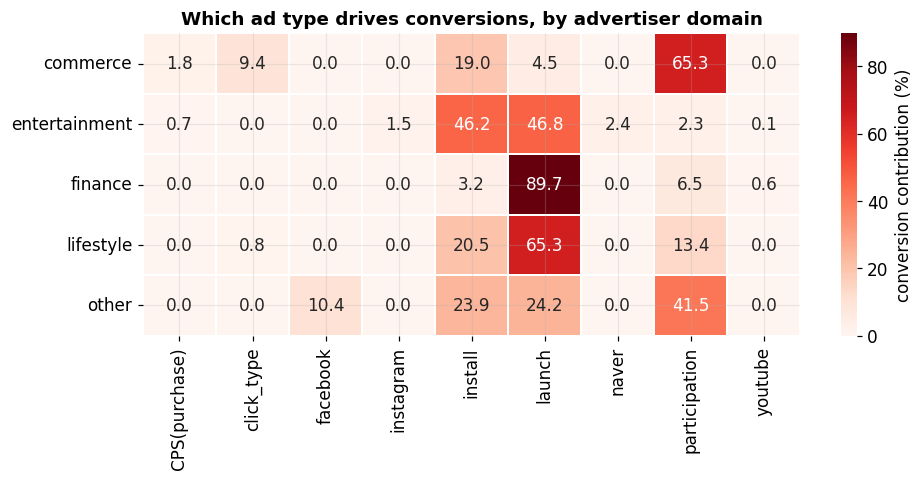

In [299]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(conv_pct, annot=True, fmt='.1f', cmap='Reds', linewidths=1, linecolor='white',
            cbar_kws={'label': 'conversion contribution (%)'}, ax=ax)
ax.set_title('Which ad type drives conversions, by advertiser domain', fontsize=12, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Strategic importance index

`score = sqrt(conversion_contribution% x budget_absorption%)` -- a geometric mean so that an ad
type which is only strong on one dimension (e.g. absorbs a lot of budget but converts nothing)
doesn't get over-ranked.


In [300]:
eff_dist = df_analysis.groupby(['domain_name','type_name']).agg(
    total_conv=('click_key','count'), total_spend=('show_cost','sum')
).reset_index()
conv_pivot  = eff_dist.pivot(index='domain_name', columns='type_name', values='total_conv').fillna(0)
spend_pivot = eff_dist.pivot(index='domain_name', columns='type_name', values='total_spend').fillna(0)
conv_pct2  = conv_pivot.div(conv_pivot.sum(axis=1), axis=0) * 100
spend_pct  = spend_pivot.div(spend_pivot.sum(axis=1), axis=0) * 100
strategic_score = np.sqrt(conv_pct2 * spend_pct).fillna(0)

col_order = ['launch','install','participation','naver','instagram','CPS(purchase)','click_type','facebook','youtube']
print(strategic_score[[c for c in col_order if c in strategic_score.columns]].round(1).to_string())

type_name      launch  install  participation  naver  instagram  CPS(purchase)  click_type  facebook  youtube
domain_name                                                                                                  
commerce          1.3      4.9           24.1    0.0        0.0           12.5         0.6       0.0      0.0
entertainment    35.7     27.4            2.5    1.7        1.0            6.0         0.0       0.0      0.0
finance          75.0      2.2           15.2    0.0        0.0            0.0         0.0       0.0      0.5
lifestyle        55.5     15.5           23.5    0.0        0.0            0.0         0.2       0.0      0.0
other            25.8     22.3           36.0    0.0        0.0            0.0         0.0      14.6      0.0


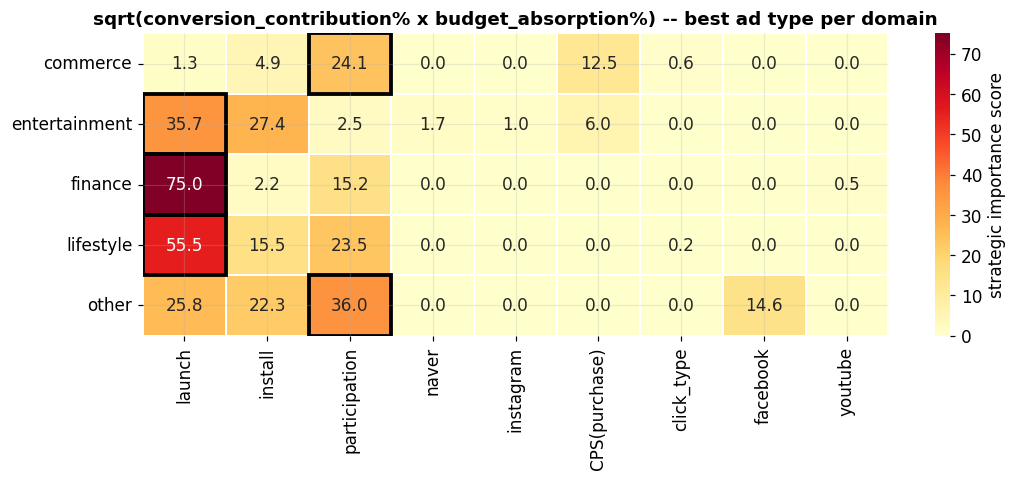

In [301]:
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_cols = [c for c in col_order if c in strategic_score.columns]
sns.heatmap(strategic_score[plot_cols], annot=True, fmt='.1f', cmap='YlOrRd', linewidths=1,
            linecolor='white', cbar_kws={'label': 'strategic importance score'}, ax=ax)
ax.set_title('sqrt(conversion_contribution% x budget_absorption%) -- best ad type per domain',
             fontsize=12, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')

# mark the top pick in each row with a box
for i, (domain, row) in enumerate(strategic_score[plot_cols].iterrows()):
    j = plot_cols.index(row.idxmax())
    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', linewidth=2.5))

plt.tight_layout()
plt.show()

**Final recommendation per domain (top pick):**

| Domain | Best ad type | Score |
|---|---|---|
| finance | launch | 75.0 |
| lifestyle | launch | 55.5 |
| other | participation | 36.0 |
| entertainment | launch | 35.7 |
| commerce | participation | 24.1 |


## ads_order (exposure position)

The naive claim "higher exposure-order number -> higher conversion probability" doesn't survive
scrutiny once controlled for ad type and confounds -- the investigation below walks through why,
and what the data actually supports instead.

In [302]:
order_bins   = [0, 500_000, 1_000_000, 1_500_000, 2_000_000, 2_500_000, 3_500_000]
order_labels = ['0-50k','50-100k','100-150k','150-200k','200-250k','250k+']

order_df = df_master[['ads_idx','ads_order']].merge(
    event_clean.groupby('ads_idx').agg(clicks=('click_key','count'), conversions=('is_conv','sum')).reset_index(),
    on='ads_idx', how='left'
).fillna(0)
order_df['order_group'] = pd.cut(order_df['ads_order'], bins=order_bins, labels=order_labels, right=True)
summary = order_df.groupby('order_group', observed=False).agg(
    total_clicks=('clicks','sum'), total_conv=('conversions','sum')
).assign(cvr=lambda x: (x['total_conv']/x['total_clicks'].replace(0,np.nan)*100).round(2))
print("[raw CVR by ads_order range — outlier-fraud only removed]")
print(summary)

[raw CVR by ads_order range — outlier-fraud only removed]
             total_clicks  total_conv    cvr
order_group                                 
0-50k                 0.0         0.0    NaN
50-100k               7.0         0.0   0.00
100-150k          26758.0     12770.0  47.72
150-200k          30885.0      6000.0  19.43
200-250k        8258002.0      5171.0   0.06
250k+           2127500.0    915801.0  43.05


The 200-250k range collapses to 0.48% CVR — first hypothesis: maybe it's still contaminated
by `abusing`-labeled (not-yet-confirmed) fraud that `event_clean` deliberately keeps. Checking media
risk-label composition of that range's traffic against `df_integrated` (which still has the full
risk breakdown) confirms this:

In [303]:
target_ads = order_df.loc[(order_df['order_group']=='200-250k') & (order_df['clicks']>0), 'ads_idx']
range_clicks = df_integrated[df_integrated['ads_idx'].isin(target_ads)]
print(range_clicks.groupby('Risk_Label').agg(
    clicks=('click_key','count'), conversions=('is_rewarded','sum')
).assign(cvr=lambda x: (x['conversions']/x['clicks']*100).round(2)))

              clicks  conversions    cvr
Risk_Label                              
critical    13568357          466   0.00
normal         12376          722   5.83
risky          15115          256   1.69
warning        29152         4251  14.58


99.5% of this range's clicks come from `critical`-risk media at 0% CVR — the range is
statistically dominated by media 539/563-type traffic. Re-running the range analysis on **fully
clean data** (both `outlier` and `abusing` removed) to control for this:

In [304]:
event_fully_clean = df_integrated[df_integrated['row_label'].isin(['normal','non_rewarded'])].copy()
clean_ads = event_fully_clean.groupby('ads_idx').agg(
    clicks=('click_key','count'), conversions=('is_rewarded','sum')).reset_index()
order_df_clean = df_master[['ads_idx','ads_order']].merge(clean_ads, on='ads_idx', how='left').fillna(0)
order_df_clean['order_group'] = pd.cut(order_df_clean['ads_order'], bins=order_bins, labels=order_labels, right=True)
clean_summary = order_df_clean.groupby('order_group', observed=False).agg(
    total_clicks=('clicks','sum'), total_conv=('conversions','sum')
).assign(cvr=lambda x: (x['total_conv']/x['total_clicks'].replace(0,np.nan)*100).round(2))
print("[fully-clean CVR by ads_order range]")
print(clean_summary)

[fully-clean CVR by ads_order range]
             total_clicks  total_conv    cvr
order_group                                 
0-50k                 0.0         0.0    NaN
50-100k               7.0         0.0   0.00
100-150k           9786.0      3638.0  37.18
150-200k          25911.0      4333.0  16.72
200-250k         813922.0      3884.0   0.48
250k+           1811011.0    799710.0  44.16


**The dip survives full fraud removal — click volume in the 200-250k range drops from 8.2M to
814k once `abusing` traffic is out, but CVR is unchanged (0.48%).** So it isn't purely a fraud
artifact. Breaking that range down by ad type on clean data:

In [305]:
type_breakdown = event_fully_clean[event_fully_clean['ads_idx'].isin(
    order_df_clean.loc[(order_df_clean['order_group']=='200-250k') & (order_df_clean['clicks']>0), 'ads_idx']
)].groupby('ads_type_name').agg(clicks=('click_key','count'), conv=('is_rewarded','sum')).assign(
    cvr=lambda x: (x['conv']/x['clicks']*100).round(2))
print(type_breakdown.sort_values('clicks', ascending=False))

# now control for ad type: does CVR still rise with ads_order INSIDE each type?
order_by_type = event_fully_clean.copy()
order_by_type['order_group'] = pd.cut(order_by_type['ads_order'], bins=order_bins, labels=order_labels, right=True)
pivot_cvr = order_by_type.groupby(['ads_type_name','order_group'], observed=False).agg(
    clicks=('click_key','count'), conv=('is_rewarded','sum')
).assign(cvr=lambda x: (x['conv']/x['clicks'].replace(0,np.nan)*100).round(2))
print("\n[CVR by ad type x ads_order range]")
print(pivot_cvr.reset_index().pivot(index='ads_type_name', columns='order_group', values='cvr'))

               clicks  conv    cvr
ads_type_name                     
participation  806841  1397   0.17
launch           3635   825  22.70
instagram        2782  1383  49.71
youtube           664   279  42.02

[CVR by ad type x ads_order range]
order_group    0-50k  50-100k  100-150k  150-200k  200-250k  250k+
ads_type_name                                                     
CPS(purchase)    NaN      0.0      1.51      4.57       NaN  27.97
click_type       NaN      NaN       NaN       NaN       NaN  98.18
facebook         NaN      NaN       NaN       NaN       NaN  28.08
instagram        NaN      NaN       NaN       NaN     49.71  73.04
install          NaN      NaN       NaN     59.10       NaN  62.81
launch           NaN      NaN       NaN      4.71     22.70  40.19
naver            NaN      NaN       NaN       NaN       NaN  53.99
participation    NaN      NaN     43.10      2.50      0.17  17.11
youtube          NaN      NaN       NaN       NaN     42.02   4.26


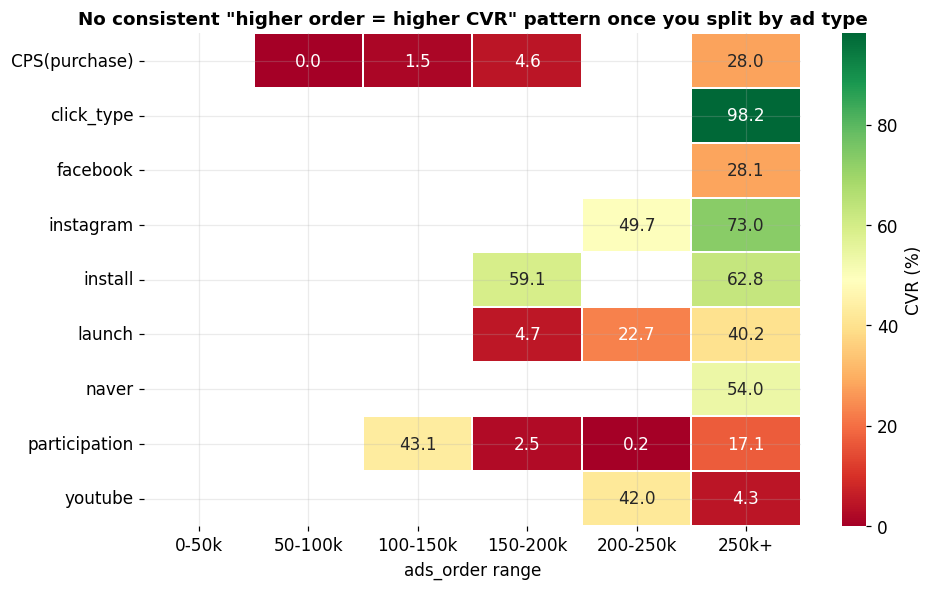

In [306]:
plot_pivot = pivot_cvr.reset_index().pivot(index='ads_type_name', columns='order_group', values='cvr')
plot_pivot = plot_pivot.reindex(columns=order_labels)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(plot_pivot, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=1, linecolor='white',
            cbar_kws={'label': 'CVR (%)'}, mask=plot_pivot.isna(), ax=ax)
ax.set_title('No consistent "higher order = higher CVR" pattern once you split by ad type',
             fontsize=12, fontweight='bold')
ax.set_xlabel('ads_order range'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [307]:
corr = df_master[['ads_order','regdate','ads_sdate']].dropna()
print(f"ads_order vs regdate corr:   {corr['ads_order'].corr(corr['regdate'].astype('int64')):.3f}")
print(f"ads_order vs ads_sdate corr: {corr['ads_order'].corr(corr['ads_sdate'].astype('int64')):.3f}")

active_ads   = df_master[df_master['ads_idx'].isin(df_engagement['ads_idx'].unique())]
inactive_ads = df_master[~df_master['ads_idx'].isin(df_engagement['ads_idx'].unique())]
print(f"\nads_order median — active ads:   {active_ads['ads_order'].median():,.0f}")
print(f"ads_order median — inactive ads: {inactive_ads['ads_order'].median():,.0f}")

ads_order vs regdate corr:   0.156
ads_order vs ads_sdate corr: 0.156

ads_order median — active ads:   1,369,869
ads_order median — inactive ads: 1,368,503


### Conclusion

1. **The naive "higher ads_order = higher CVR" claim is rejected.** Within `participation` (86% of
   platform volume) CVR moves 43.10% -> 2.50% -> 0.17% -> 17.11% across order ranges — not
   monotonic, and the exact opposite direction from `launch` (4.71% -> 22.70% -> 40.19%,
   monotonically increasing) and `youtube` (42.02% -> 4.26%, decreasing). **Different ad types move
   in different or opposite directions**, so there's no single "exposure order effect" to report.
2. **`ads_order` is not a registration-recency proxy either, and has no meaningful relationship to
   whether an ad ever gets engagement.** Correlation with `regdate`/`ads_sdate` is negligible
   (r=0.156), and the median `ads_order` for active vs. inactive ads is effectively identical
   (1,369,869 vs 1,368,503).
3. **Practical takeaway:** the platform should not optimize ad placement using `ads_order` as a
   general-purpose signal — points 1-2 together leave nothing about `ads_order` that survived
   scrutiny. The domain x ad-type strategic-importance index (above) is a materially
   better-supported basis for that decision, and this investigation is itself a demonstration of
   why the fraud-detection work in Part 1 matters — an unscrubbed metric here would have shipped a
   wrong operational recommendation.

---
# Summary, known limitations, and future work

## Result summary

| Area | Result |
|---|---|
| High-confidence anomaly | 38.0% of clicks; 46.2% more flagged for monitoring; 4.8% clean |
| CVR (raw vs. remaining low-risk traffic) | 8.74% -> 30.50% (same traffic, narrower slice -- not a claim that any intervention was applied) |
| Financial exposure quantified | 260.7M KRW total (67.1M high-confidence + 193.6M monitoring-band) |
| Exposure concentration | 2 of 189 media = 75.5% of high-confidence exposure |
| Media typology | 1 acute infiltration, 2 chronic high-share, 16 chronic low-share |
| 1-year validation | the flagged media had a normal-looking CVR for 13 months, then collapsed in the analyzed month |
| Threshold sensitivity | top-4 highest-exposure media (58, 342, 563, 761) stable across a 3x range of threshold strictness (Step 18) |
| Out-of-time backtest | click-share signal alone would have flagged media 539 one day before its visible plateau; the combined share+CVR rule as designed would have missed it (Step 19b) |
| Media segmentation | 189 media -> confirmed/potential/improve/reduce recommendations, with documented percentile thresholds and a 3.9% low-sample-size caveat |
| Domain ad-type fit | data-backed top pick per domain via a geometric-mean strategic importance index |

## Known limitations

1. **No independently verified ground truth.** Every anomaly label in this notebook is a
   statistical extreme relative to this platform's own traffic distribution -- there is no
   confirmed-invalid-traffic or settlement-rejection label to check against. Terminology
   throughout is calibrated to this (see Part 1 summary's terminology table); manual review by a
   human looking at the same features the rules use is deliberately not used as a validation step,
   since it would be circular rather than independent evidence.
2. **Look-ahead bias in the main pipeline.** The CTIT/device/click thresholds used everywhere
   except Step 19b are computed from the same 31-day window that contains the August anomaly --
   appropriate for retrospective discovery, not for claiming an operational detector. Step 19b's
   out-of-time backtest (rolling baseline, `.shift(1)`) is the one place in this notebook that
   avoids this.
3. **Domain labeling** is a rule + LLM hybrid classifier; a 100-row manual audit found ~6-7 clear
   errors, concentrated in the `other` bucket. 9 specific errors are patched (Step 1a) at the
   source so both `df_master` and everything derived from it inherit the fix; a full stratified
   audit of all 5 domains has not been done.
4. **Small-sample media recommendations**: 3.9% of confirmed/potential media recommendations in
   Part 2 rest on ad types with fewer than 10 media, where the reliability gate is relaxed.
5. **`ads_order`** does not carry the simple interpretation a naive read of the raw numbers
   suggests -- see Part 3 for the full investigation.
6. **Media-risk thresholds are also heuristic** (critical = extreme_ratio >= 30%, etc.) and have
   not been sensitivity-tested the way the row-level thresholds have (Step 18).
7. **Media-risk rates have no confidence interval.** A media with 4 clicks and 40% extreme_ratio
   currently gets the same `critical` label as one with 1M clicks and 35% -- no distinction is
   made for sample size (Wilson CI / Beta-Binomial shrinkage would address this; not implemented).
8. **The AND-gate alert design in Step 19b is media-specific, not validated platform-wide.** It
   was shown to be too conservative for media 539 (its own CVR volatility masks the collapse in
   z-score terms); whether a share-only or OR-combined rule generalizes to other media is an open
   question.

## Future work

Deliberately not attempted here, listed so a reader knows they were considered rather than missed:

- **Rule-based vs. unsupervised comparison** (Isolation Forest). A version worth trusting would
  run at the media x IP grain (not per-click, which duplicates IP-level features across every row
  and overrepresents high-volume IPs) with a richer feature set (unique ads touched, active
  hours/days, inter-click interval statistics), matching the model's anomaly budget to the rule's
  flagged rate before comparing.
- **IP-device bipartite graph analysis** (NetworkX) -- connected-component size and edge density
  as a device-farm signature, complementary to the current per-IP percentile thresholds.
- **Inter-click interval features** (median/CV of time between clicks, burst detection) -- a
  behavioral signal that doesn't currently exist in this pipeline; automated scripts often show
  suspiciously uniform intervals that click-count alone can't distinguish from an engaged human.
- **Media-risk confidence intervals** (Wilson / Beta-Binomial shrinkage) per limitation #7 above.
- **Signal ablation / overlap analysis** -- what fraction of `outlier` clicks are flagged by CTIT
  alone vs. device alone vs. click-count alone vs. combinations, to check whether the 3-signal
  detector is really doing 3 signals' worth of work or is dominated by one.
- **Peer-group (media-size-relative) thresholds** instead of one global percentile cutoff, so a
  large legitimate media isn't structurally more likely to cross an absolute-count threshold than
  a small one.
- **Platform-wide validation of a share-only or OR-combined alert rule**, generalizing the Step
  19b finding beyond the single media it was tested on.

## Individual contribution

Data integration, missing-value/outlier handling (Step 2, 13), feature engineering (Step 3),
fraud detection & scoring (Steps 5-9), 1-year validation (Steps 13-19b), domain-label correction,
acute/chronic reclassification, the `ads_order` investigation, threshold sensitivity, and the
out-of-time backtest -- **Part 1 in full** -- are the author's individual work. Part 2 (Media
Operations Management) and Part 3 (Domain Ad Optimization) were built by teammates and are
included for pipeline continuity.
